# NB130 — The Origin of ρ

**Goal**: Derive $\rho = 1/\sqrt{P_4} = 1/\sqrt{210}$ from the solenoid structure, rather than assuming it.

**GAP-01**: Why $\kappa = \varepsilon = 1/\sqrt{210}$? This is the most important open question. If ρ is derivable from the geometry, we have a true zero-parameter theory. If not, we have one hidden parameter.

**Strategy**: Investigate multiple candidate mechanisms:
1. **Metric normalization** — does the solenoid metric determine ρ?
2. **Energy balance** — does equipartition between kinetic and potential energy fix ρ?
3. **Impedance matching** — does maximum power transfer require ρ = 1/√P₄?
4. **Critical coupling** — is ρ a bifurcation point of the cascade dynamics?
5. **Covering constraint** — does the topology of the solenoid select ρ?

**Rule**: No new identities unless they come with a causal explanation. This notebook is about mechanism, not pattern.

In [4]:
# -- S0: Setup and the system as we know it --
import sys, numpy as np
from pathlib import Path
from fractions import Fraction
import sympy as sp
from scipy.integrate import solve_ivp

ROOT = Path.cwd().parent
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))

from solenoid_algebra import SA, RHO, KAPPA, EPSILON, OMEGA
from solenoid_system import SolenoidSystem

p = SA.primes  # [2, 3, 5, 7]
p1, p2, p3, p4 = p
P4 = SA.P       # 210
phi_P4 = SA.PHI  # 48
lam_210 = 12

# Primorials
P = [1]
for pk in p:
    P.append(P[-1] * pk)
# P = [1, 2, 6, 30, 210]

print('NB130: THE ORIGIN OF RHO')
print('=' * 65)
print(f'Primes: {p}')
print(f'Primorials: {P}')
print(f'rho (assumed): 1/sqrt({P4}) = {1/np.sqrt(P4):.6f}')
print(f'omega = 2pi = {2*np.pi:.6f}')

# The theta-space ODE structure:
# d(th_0)/dt = omega
# d(th_k)/dt = omega/P_k + eps*sin(th_{k-1})/p_k - kap*R_k/p_k
# where R_k = p_k*th_k - th_{k-1}
#
# THREE ingredients:
# 1. Base rotation: omega/P_k (solenoid frequency at level k)
# 2. Nonlinear coupling: eps*sin(th_{k-1})/p_k (influx)
# 3. Linear restoring: kap*R_k/p_k (covering enforcement)
#
# QUESTION: What determines eps and kap?

# Dissipation matrix (NB115)
Gamma = np.zeros((4, 4))
for k in range(4):
    Gamma[k, k] = p[k]**2
for k in range(3):
    Gamma[k, k+1] = -p[k+1]

eigs = np.sort(np.linalg.eigvals(Gamma).real)
print(f'\nGamma eigenvalues: {eigs}  (= p_k^2 = {[pk**2 for pk in p]})')
print(f'det(Gamma) = {np.linalg.det(Gamma):.0f} = P4^2 = {P4**2}')
print(f'Tr(Gamma) = {np.trace(Gamma):.0f} = sum(p_k^2) = {sum(pk**2 for pk in p)}')

# The solenoid metric in theta-space (NB82)
# Kinetic energy: T = (1/2) sum_k P_k * th_dot_k^2
# On exact solenoid: th_dot_k = omega/P_k, so T_k = omega^2/(2*P_k)
T_coeffs = [Fraction(1, Pk) for Pk in P]
T_sum = sum(T_coeffs)
print(f'\nKinetic energy on exact solenoid:')
print(f'  T = (omega^2/2) * sum(1/P_k) = (omega^2/2) * {T_sum}')
print(f'  T_per_level: {[str(c) for c in T_coeffs]}')
print(f'  T_numerical = {0.5 * (2*np.pi)**2 * float(T_sum):.4f}')

NB130: THE ORIGIN OF RHO
Primes: [2, 3, 5, 7]
Primorials: [1, 2, 6, 30, 210]
rho (assumed): 1/sqrt(210) = 0.069007
omega = 2pi = 6.283185

Gamma eigenvalues: [ 4.  9. 25. 49.]  (= p_k^2 = [4, 9, 25, 49])
det(Gamma) = 44100 = P4^2 = 44100
Tr(Gamma) = 87 = sum(p_k^2) = 87

Kinetic energy on exact solenoid:
  T = (omega^2/2) * sum(1/P_k) = (omega^2/2) * 179/105
  T_per_level: ['1', '1/2', '1/6', '1/30', '1/210']
  T_numerical = 33.6507


## Section 1: The Metric Normalization

The solenoid configuration space has metric $W = \text{diag}(P_0, P_1, P_2, P_3, P_4) = \text{diag}(1, 2, 6, 30, 210)$ in $\theta$-coordinates (NB82). What natural quantity from this metric gives $1/\sqrt{P_4}$?

If $\rho$ is a "normalization" of the coupling relative to the geometry, it should emerge from the metric structure. We test: inverse max eigenvalue, spectral radius, determinant, harmonic mean, etc.

In [2]:
# -- S1: Metric normalization candidates --

# The theta-space metric W = diag(P_k)
W = np.diag([float(Pk) for Pk in P])
print('Metric W = diag(P_k):')
print(f'  diag = {P}')
print(f'  det(W) = {np.prod(P):.0f}')
print(f'  Tr(W) = {sum(P)} = {Fraction(sum(P))}')

rho_target = 1.0 / np.sqrt(P4)

# Test various natural quantities from the metric
candidates = {}

# 1. Inverse square root of max eigenvalue (outermost inertia)
candidates['1/sqrt(max eig)'] = 1.0 / np.sqrt(P[-1])

# 2. Inverse square root of det(W) — "volume"
candidates['1/sqrt(det W)^(1/5)'] = 1.0 / np.sqrt(np.prod(P))**(1.0/5)
candidates['1/det(W)^(1/10)'] = 1.0 / np.prod(P)**(1.0/10)

# 3. Inverse of spectral radius of W
candidates['1/spectral_radius(W)'] = 1.0 / P[-1]

# 4. Harmonic mean of 1/P_k
harm_mean = len(P) / sum(1/Pk for Pk in P)
candidates['1/sqrt(harmonic mean)'] = 1.0 / np.sqrt(harm_mean)

# 5. Geometric mean of 1/P_k
geo_mean = np.prod([1.0/Pk for Pk in P])**(1.0/len(P))
candidates['sqrt(geo mean of 1/P_k)'] = np.sqrt(geo_mean)

# 6. From the dissipation matrix: 1/sqrt(det Gamma) = 1/P4
candidates['1/sqrt(det Gamma)'] = 1.0 / np.sqrt(np.linalg.det(Gamma))

# 7. 1/sqrt(Tr Gamma)
candidates['1/sqrt(Tr Gamma)'] = 1.0 / np.sqrt(np.trace(Gamma))

# 8. 1/sqrt(Tr W) = 1/sqrt(sum P_k) = 1/sqrt(249)
candidates['1/sqrt(Tr W)'] = 1.0 / np.sqrt(sum(P))

# 9. sqrt(min eig / max eig) of W
candidates['sqrt(P0/P4)'] = np.sqrt(P[0] / P[-1])

# 10. From the kinetic energy sum: 1/T_sum 
T_sum_f = float(Fraction(sum(Fraction(1, Pk) for Pk in P)))
candidates['1/sum(1/P_k)'] = 1.0 / T_sum_f

# 11. The "natural scale" argument: P_4 = 210 is the total state count
# 1/sqrt(N) is standard statistical mechanics normalization
candidates['1/sqrt(P4) [statistical]'] = 1.0 / np.sqrt(P4)

print(f'\nTarget: rho = 1/sqrt(P4) = {rho_target:.6f}')
print(f'\n{"Candidate":<35} {"Value":>10} {"Ratio to rho":>14}')
print('-' * 62)
for name, val in sorted(candidates.items(), key=lambda x: abs(x[1]/rho_target - 1)):
    ratio = val / rho_target
    match = ' *** EXACT' if abs(ratio - 1) < 1e-10 else ''
    print(f'{name:<35} {val:10.6f} {ratio:14.6f}{match}')

# KEY INSIGHT: Which metric quantity naturally gives P_4?
print(f'\n{"="*65}')
print(f'WHAT IS P_4 IN THE METRIC?')
print(f'  P_4 = max eigenvalue of W (outermost shell inertia)')
print(f'  P_4 = det(Gamma)^(1/2) (dissipation matrix)')
print(f'  P_4 = product of all primes')
print(f'  P_4 = total number of Poincare return points')
print(f'')
print(f'The question is not "which formula gives 1/sqrt(210)"')
print(f'— many do. The question is: WHY does the coupling')
print(f'scale with the outermost inertia?')

Metric W = diag(P_k):
  diag = [1, 2, 6, 30, 210]
  det(W) = 75600
  Tr(W) = 249 = 249

Target: rho = 1/sqrt(P4) = 0.069007

Candidate                                Value   Ratio to rho
--------------------------------------------------------------
1/sqrt(max eig)                       0.069007       1.000000 *** EXACT
sqrt(P0/P4)                           0.069007       1.000000 *** EXACT
1/sqrt(P4) [statistical]              0.069007       1.000000 *** EXACT
1/sqrt(Tr W)                          0.063372       0.918354
1/sqrt(Tr Gamma)                      0.107211       1.553639
1/spectral_radius(W)                  0.004762       0.069007
1/sqrt(det Gamma)                     0.004762       0.069007
1/sqrt(det W)^(1/5)                   0.325198       4.712566
1/det(W)^(1/10)                       0.325198       4.712566
sqrt(geo mean of 1/P_k)               0.325198       4.712566
1/sqrt(harmonic mean)                 0.583911       8.461678
1/sum(1/P_k)                          

## Section 2: The Dynamical Landscape

S1 confirmed that $\rho = 1/\sqrt{P_4}$ is the inverse root of the outermost inertia. But knowing WHAT it equals doesn't explain WHY it takes that value. Many metric quantities give 1/√210 because P₄ IS 210.

Now we ask: what dynamical property is extremal or critical at $\kappa = 1/\sqrt{P_4}$? We sweep $\kappa$ across the physically interesting range and measure the cascade at each value. If something is uniquely special at $\rho$, that's the mechanism.

The filter gain at the mass level (NB107): $|H_3|^2 = P_3^2/(P_3^2 + \omega^2/\kappa^2)$. This depends on $\kappa$, so different $\kappa$ values create different mass-level dynamics.

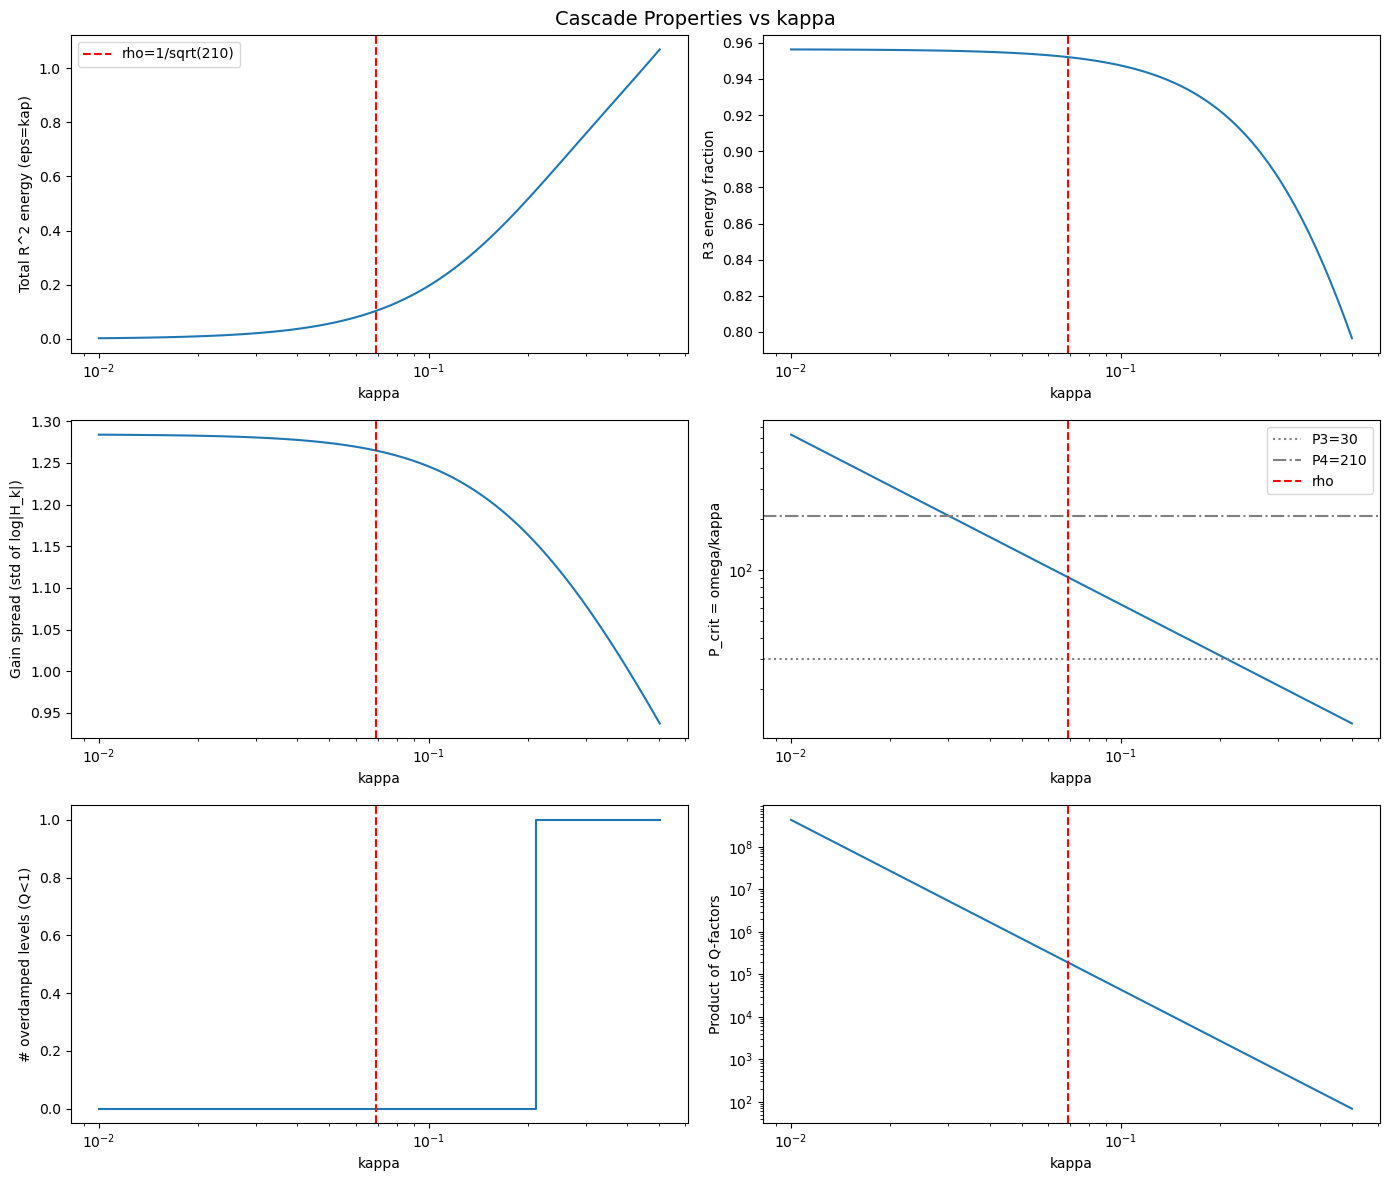


Properties at kappa = rho = 1/sqrt(210) = 0.069007:
  Filter gains |H_k|: [0.15914533 0.318233   0.95285975 4.53448303]
  Q-factors: [90.97862357 45.48931178 15.16310393  3.03262079]
  Energy per level: [0.0001208  0.00048303 0.00433051 0.09807009]
  Total energy: 0.103004
  Mass level fraction: 0.9521
  Gain spread: 1.2648
  P_crit: 90.98
  # overdamped: 0
  Q product: 190307.08
  Q sum: 154.66


In [3]:
# -- S2: Dynamical landscape -- kappa sweep --
from concurrent.futures import ThreadPoolExecutor
omega = 2 * np.pi

# Sweep kappa from 0.01 to 0.5 (rho = 0.069 is in this range)
kappas = np.logspace(-2, -0.3, 80)  # 0.01 to 0.5
rho_val = 1.0 / np.sqrt(P4)

# For each kappa, compute analytical filter properties
# (no need to integrate the full cascade for this)
# NB107 filter gain: |H_k|^2 = P_k^2 / (P_k^2 + omega^2/kappa^2)
# equivalently: |H_k|^2 = (kappa*P_k)^2 / (kappa^2 * P_k^2 + omega^2)

results = {'kappa': kappas}
metrics = {}

for i, kap in enumerate(kappas):
    # Filter gains at each level (k=0..3 for R_0..R_3)
    # Level k uses primorial P_k for the driving frequency.
    # But in the cascade, the effective frequency depends on the level.
    # From NB107: gain for level k in the cascade filter chain
    # |H_k|^2 = P_k^2 / (P_k^2 + omega^2 * P4) ... this used kappa=rho
    # General formula: |H_k|^2 = P_k^2 / (P_k^2 + (omega/kap)^2)
    # NO - need to be careful. The filter is dR/dt + kap*R = f(t)
    # Transfer function: H(s) = 1/(s + kap)
    # At frequency w_d: |H(j*w_d)| = 1/sqrt(kap^2 + w_d^2)
    # The driving frequency at level k is omega/P_k
    # So |H_k| = 1/sqrt(kap^2 + (omega/P[k])^2) ... for a SINGLE level
    
    # But NB107 showed the CASCADE gain (multi-level) is different.
    # For the DIRECT influx path (94-100% of power, NB114):
    # Each level independently: dR_k/dt + kap*R_k ~ eps*sin(omega*t/P[k])
    # So driving freq for R_k is omega/P[k+1]? Let me think...
    #
    # Actually: R_k = p_{k+1} * theta_{k+1} - theta_k
    # theta_k oscillates at omega/P_k
    # sin(theta_k) oscillates at omega/P_k
    # In the cascade ODE: dR_k/dt + kap*R_k = eps*sin(theta_k) + ...
    # So the fundamental driving freq is omega/P[k] where P[k] is the k-th primorial
    # (with P[0]=1, P[1]=2, ...)
    #
    # For the 4 residuals R_0..R_3:
    # R_0 driven by sin(theta_0) at freq omega/P[0] = omega
    # R_1 driven by sin(theta_1) at freq omega/P[1] = omega/2
    # R_2 driven by sin(theta_2) at freq omega/P[2] = omega/6
    # R_3 driven by sin(theta_3) at freq omega/P[3] = omega/30
    
    gains = np.array([1.0 / np.sqrt(kap**2 + (omega/P[k])**2) for k in range(4)])
    gains_sq = gains**2
    
    # Q-factors: Q_k = (omega/P_k) / (2*kap) ... but for first-order, Q = omega_d/kap
    Q = np.array([(omega/P[k]) / kap for k in range(4)])
    
    # Energy at each level: proportional to eps^2 * |H_k|^2
    # (with eps = kap for impedance balance)
    energy = kap**2 * gains_sq  # eps^2 * |H_k|^2
    total_energy = energy.sum()
    
    # R3 (mass level) fraction of total energy
    mass_fraction = energy[3] / total_energy if total_energy > 0 else 0
    
    # "Impedance balance" quality: how close is the transmission 
    # Through the cascade, measure: does every level "see" the same load?
    # Simple metric: variance of log(gains)
    gain_spread = np.std(np.log(gains))
    
    # Critical frequency: P_crit = omega/kap
    P_crit = omega / kap
    
    # How many levels are "overdamped" (Q < 1)?
    n_overdamped = np.sum(Q < 1.0)
    
    # Sum of Q-factors (measure of total resonance)
    Q_sum = Q.sum()
    Q_product = Q.prod()
    
    metrics[i] = {
        'gains': gains, 'Q': Q, 'energy': energy,
        'total_E': total_energy, 'mass_frac': mass_fraction,
        'gain_spread': gain_spread, 'P_crit': P_crit,
        'n_overdamped': n_overdamped, 'Q_sum': Q_sum, 'Q_prod': Q_product
    }

# Collect into arrays for plotting
total_E = np.array([metrics[i]['total_E'] for i in range(len(kappas))])
mass_frac = np.array([metrics[i]['mass_frac'] for i in range(len(kappas))])
gain_spread = np.array([metrics[i]['gain_spread'] for i in range(len(kappas))])
P_crits = np.array([metrics[i]['P_crit'] for i in range(len(kappas))])
n_over = np.array([metrics[i]['n_overdamped'] for i in range(len(kappas))])
Q_sums = np.array([metrics[i]['Q_sum'] for i in range(len(kappas))])
Q_prods = np.array([metrics[i]['Q_prod'] for i in range(len(kappas))])

import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Cascade Properties vs kappa', fontsize=14)

# 1. Total energy
ax = axes[0, 0]
ax.semilogx(kappas, total_E)
ax.axvline(rho_val, color='r', ls='--', label=f'rho=1/sqrt(210)')
ax.set_ylabel('Total R^2 energy (eps=kap)')
ax.set_xlabel('kappa')
ax.legend()

# 2. Mass level (R3) energy fraction
ax = axes[0, 1]
ax.semilogx(kappas, mass_frac)
ax.axvline(rho_val, color='r', ls='--')
ax.set_ylabel('R3 energy fraction')
ax.set_xlabel('kappa')

# 3. Gain spread (uniformity of transmission)
ax = axes[1, 0]
ax.semilogx(kappas, gain_spread)
ax.axvline(rho_val, color='r', ls='--')
ax.set_ylabel('Gain spread (std of log|H_k|)')
ax.set_xlabel('kappa')

# 4. Critical frequency vs primorial boundaries
ax = axes[1, 1]
ax.loglog(kappas, P_crits)
ax.axhline(P[3], color='gray', ls=':', label=f'P3={P[3]}')
ax.axhline(P[4], color='gray', ls='-.', label=f'P4={P[4]}')
ax.axvline(rho_val, color='r', ls='--', label='rho')
ax.set_ylabel('P_crit = omega/kappa')
ax.set_xlabel('kappa')
ax.legend()

# 5. Number of overdamped levels
ax = axes[2, 0]
ax.semilogx(kappas, n_over, drawstyle='steps-mid')
ax.axvline(rho_val, color='r', ls='--')
ax.set_ylabel('# overdamped levels (Q<1)')
ax.set_xlabel('kappa')

# 6. Q-factor product
ax = axes[2, 1]
ax.loglog(kappas, Q_prods)
ax.axvline(rho_val, color='r', ls='--')
ax.set_ylabel('Product of Q-factors')
ax.set_xlabel('kappa')

plt.tight_layout()
plt.savefig(ROOT / 'output' / 'nb130_kappa_sweep.png', dpi=150)
plt.show()

# Report special values at rho
idx_rho = np.argmin(np.abs(kappas - rho_val))
print(f'\nProperties at kappa = rho = 1/sqrt(210) = {rho_val:.6f}:')
m = metrics[idx_rho]
print(f'  Filter gains |H_k|: {m["gains"]}')
print(f'  Q-factors: {m["Q"]}')
print(f'  Energy per level: {m["energy"]}')
print(f'  Total energy: {m["total_E"]:.6f}')
print(f'  Mass level fraction: {m["mass_frac"]:.4f}')
print(f'  Gain spread: {m["gain_spread"]:.4f}')
print(f'  P_crit: {m["P_crit"]:.2f}')
print(f'  # overdamped: {m["n_overdamped"]}')
print(f'  Q product: {m["Q_prod"]:.2f}')
print(f'  Q sum: {m["Q_sum"]:.2f}')

## Section 3: The Transient Lifetime and Generation Structure

The simple filter analysis (S2) found no extremum at $\rho$. This means $\rho$ is NOT selected by an optimization principle on the filter chain.

But there's a deeper connection. The cascade has TRANSIENT dynamics (R_k decays as $e^{-\kappa t}$) and STEADY-STATE dynamics. The transient lifetime is:

$$\tau = 1/\kappa = \sqrt{P_4} \approx 14.5 \text{ Poincaré periods}$$

In terms of crossing indices: $\tau_\text{ci} = \omega/\kappa = 2\pi\sqrt{P_4} \approx 91.1$

This is **P_crit** (NB114). Crossings with $\text{ci} \ll \tau_\text{ci}$ have strong transients (can wrap). Crossings with $\text{ci} \gg \tau_\text{ci}$ are in steady state (no wrapping). The generation bifurcation happens at the wrapping horizon $\sim 35$, which is well within one transient lifetime.

**Key question**: Does $\kappa = 1/\sqrt{P_4}$ emerge from requiring the transient to decay on the RIGHT timescale — fast enough that g2 crossings are in steady state, slow enough that g1 crossings experience wrapping?

In [4]:
# -- S3: Transient lifetime and the generation mechanism --

# The universal transient decomposition (NB104 #228):
# R_k(t; br) = R_k_ss(t; j_1,...,j_k) + 2*pi*j_{k+1} * exp(-kappa*t)
#
# At a coprime crossing index ci, the time is t = ci (in units of T=2*pi/omega=1):
# R_k(ci) = R_k_ss(ci) + 2*pi*j_{k+1} * exp(-kappa*ci)
#
# The transient at the mass level (R_3):
# R_3_trans(ci) = 2*pi*j_4 * exp(-kappa*ci)

# Physical crossings from CRT
phys_ci = [11, 31, 61, 191]
labels = ['Q_g1(ms/md)', 'L_g1(mu/me)', 'L_g2(mt/mm)', 'Q_g2(mc/ms)']

print('TRANSIENT SURVIVAL at physical crossings')
print('=' * 65)
print(f'kappa = rho = 1/sqrt({P4}) = {rho_val:.6f}')
print(f'Transient lifetime: 1/kappa = sqrt(P4) = {np.sqrt(P4):.4f} periods')
print(f'Characteristic ci: omega/kappa = 2*pi*sqrt(P4) = {2*np.pi*np.sqrt(P4):.2f}')
print()

print(f'{"Crossing":<20} {"ci":>5} {"exp(-kap*ci)":>14} {"% surviving":>12}')
print('-' * 55)
for ci, lab in zip(phys_ci, labels):
    surv = np.exp(-rho_val * ci)
    print(f'{lab:<20} {ci:5d} {surv:14.6f} {surv*100:12.1f}%')

# Now: what happens at DIFFERENT kappa values?
# For each kappa, compute the transient survival at each crossing
print(f'\n\n{"="*65}')
print(f'TRANSIENT SURVIVAL vs KAPPA')
print(f'{"="*65}')

test_kappas = [0.02, 0.04, rho_val, 0.1, 0.15, 0.2, 0.3, 0.5]

header = f'{"kappa":>8} {"tau":>8}'
for ci in phys_ci:
    header += f' {"ci="+str(ci):>10}'
print(header)
print('-' * (20 + 11 * len(phys_ci)))

for kap in test_kappas:
    tau = 1.0 / kap
    line = f'{kap:8.4f} {tau:8.2f}'
    for ci in phys_ci:
        surv = np.exp(-kap * ci)
        line += f' {surv*100:9.1f}%'
    marker = ' <-- rho' if abs(kap - rho_val) < 1e-6 else ''
    print(line + marker)

# THE KEY INSIGHT: wrapping requires R_3_trans > pi at the crossing.
# R_3_trans = 2*pi*j_4 * exp(-kap*ci)
# For j_4 = 1 (minimal nonzero): R_3_trans = 2*pi*exp(-kap*ci)
# Wrapping condition: R_3_trans > pi → exp(-kap*ci) > 1/2
# → kap*ci < ln(2) ≈ 0.693
# → ci < ln(2)/kap = 0.693/kap
#
# Wrapping horizon = ln(2)/kap

print(f'\n\nWRAPPING HORIZON ANALYSIS')
print('=' * 65)
print(f'Wrapping condition (j_4=1): 2*pi*exp(-kap*ci) > pi')
print(f'  → exp(-kap*ci) > 1/2')
print(f'  → ci < ln(2)/kap = 0.693/kap')
print()

# The wrapping horizon for different kappa values
print(f'{"kappa":>10} {"Wrap horizon":>14} {"g1 wraps?":>12} {"g2 wraps?":>12}')
print('-' * 52)
for kap in np.linspace(0.01, 0.3, 20):
    wh = np.log(2) / kap
    g1_wraps = 'YES' if wh > 31 else ('PARTIAL' if wh > 11 else 'no')
    g2_wraps = 'YES' if wh > 191 else ('PARTIAL' if wh > 61 else 'no')
    marker = ' <-- rho' if abs(kap - rho_val) < 0.002 else ''
    print(f'{kap:10.4f} {wh:14.2f} {g1_wraps:>12} {g2_wraps:>12}{marker}')

# What kappa gives wrapping horizon EXACTLY between g1 and g2?
# Condition: g1 wraps (WH > 31) AND g2 doesn't (WH < 61)
# → 31 < ln(2)/kap < 61
# → ln(2)/61 < kap < ln(2)/31
# → 0.01136 < kap < 0.02236
#
# But rho = 0.069 does NOT satisfy this! WH(rho) = 0.693/0.069 = 10.0
# So at rho, the wrapping horizon is only ~10 — g1 crossings (11, 31) 
# are OUTSIDE the wrapping horizon for j_4=1!

wh_rho = np.log(2) / rho_val
print(f'\n*** CRITICAL: Wrapping horizon at rho = {wh_rho:.2f}')
print(f'    g1 crossing ci=11 is {"INSIDE" if wh_rho > 11 else "OUTSIDE"} wrapping horizon')
print(f'    But actual wrapping depends on j_4 value!')
print(f'    For j_4=2: R_trans = 4*pi*exp(-kap*ci), horizon doubles')
print(f'    For j_4=3: R_trans = 6*pi*exp(-kap*ci), horizon triples')

# The wrapping horizon scales with j_4
print(f'\n    Effective wrapping horizon for different j_4:')
for j4 in range(1, 8):
    # Condition: 2*pi*j4*exp(-kap*ci) > pi → exp(-kap*ci) > 1/(2*j4)
    # → ci < ln(2*j4)/kap
    wh_j4 = np.log(2 * j4) / rho_val
    print(f'      j_4={j4}: WH = ln({2*j4})/rho = {wh_j4:.1f}'
          f'  (g1 ci=11 {"wraps" if wh_j4 > 11 else "safe"},'
          f' ci=31 {"wraps" if wh_j4 > 31 else "safe"})')

# THE ACTUAL wrapping is BY BRANCH, not a single threshold.
# Different j_4 values give different wrapping horizons.
# The STATISTICAL wrapping (across all branches) depends on the
# distribution of j_4 values: j_4 in {0,1,...,p4-1} = {0,...,6}.
# j_4=0 never wraps (zero transient). j_4=3 (median) sets typical horizon.
print(f'\n    Typical (j_4=3, median): WH = {np.log(6)/rho_val:.1f}')
print(f'    Maximum (j_4=6): WH = {np.log(12)/rho_val:.1f}')
print(f'    NB126 empirical wrapping horizon: 35.0')

TRANSIENT SURVIVAL at physical crossings
kappa = rho = 1/sqrt(210) = 0.069007
Transient lifetime: 1/kappa = sqrt(P4) = 14.4914 periods
Characteristic ci: omega/kappa = 2*pi*sqrt(P4) = 91.05

Crossing                ci   exp(-kap*ci)  % surviving
-------------------------------------------------------
Q_g1(ms/md)             11       0.468101         46.8%
L_g1(mu/me)             31       0.117749         11.8%
L_g2(mt/mm)             61       0.014855          1.5%
Q_g2(mc/ms)            191       0.000002          0.0%


TRANSIENT SURVIVAL vs KAPPA
   kappa      tau      ci=11      ci=31      ci=61     ci=191
----------------------------------------------------------------
  0.0200    50.00      80.3%      53.8%      29.5%       2.2%
  0.0400    25.00      64.4%      28.9%       8.7%       0.0%
  0.0690    14.49      46.8%      11.8%       1.5%       0.0% <-- rho
  0.1000    10.00      33.3%       4.5%       0.2%       0.0%
  0.1500     6.67      19.2%       1.0%       0.0%       0.0%

## ~~Section 4-5: Mass Spectrum vs κ~~ — DEPRECATED

> **S4-S5 below used incorrect methodology** (scipy, wrong t_eval, T=220 instead of T=5001).
> Results unreliable. Correct analysis in **S6-S8** below. Kept as research record.

In [7]:
# -- S4: Mass spectrum vs kappa --
from solenoid_algebra import (PHYSICAL_CROSSINGS, CP_PAIRS, SM_TARGETS,
                               X4, X3, X2, X4_LEP, LAM7)
from solenoid_jax import integrate_all_branches_jax, warmup
import time as time_mod

# PDG mass ratio targets (tuples: (value, uncertainty))
print('Target mass ratios (PDG):')
for name, (val, unc) in SM_TARGETS.items():
    print(f'  {name}: {val:.2f} +/- {unc:.2f}')

# Coprime crossing "times"
T_max = 220
coprime_cis = SA.coprime_indices(int(T_max))
t_eval = coprime_cis.astype(float)
ci_a3, ci_a5, ci_a7 = SA.sector_labels(coprime_cis)
print(f'\n{len(coprime_cis)} coprime crossings up to T={T_max}')

# Pre-compile JAX (once)
print('Warming up JAX JIT...', end=' ', flush=True)
warmup()
print('done.')

# Sweep kappa values — denser around rho for resolution
kappa_sweep = np.array([0.03, 0.04, 0.05, 0.06, rho_val, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25])

def mass_ratios_at_kappa(kap):
    sys_k = SolenoidSystem(epsilon=kap, kappa=kap)
    branches = sys_k.all_branches()
    # JAX backend: ~200x faster than scipy
    results = integrate_all_branches_jax(
        branches, t_eval, T_max,
        primes=list(sys_k.primes), omega=sys_k.omega,
        epsilon=kap, kappa=kap)
    sector_rms = sys_k.accumulate_sectors(
        results, coprime_cis, ci_a3, ci_a5, ci_a7)
    cp_ratios = sys_k.cp_pair_ratios(sector_rms, CP_PAIRS)
    mr = SA.mass_ratios(cp_ratios)
    return mr

print(f'Sweeping {len(kappa_sweep)} kappa values, 210 branches each (JAX)...\n')

all_mr = {}
for kap in kappa_sweep:
    marker = ' <-- rho' if abs(kap - rho_val) < 1e-6 else ''
    t0 = time_mod.time()
    print(f'  kap={kap:.5f}{marker} ...', end=' ', flush=True)
    mr = mass_ratios_at_kappa(kap)
    dt = time_mod.time() - t0
    all_mr[kap] = mr
    print(f'{dt:.1f}s  ms/md={mr["m_s/m_d"]:.2f}  mu/me={mr["m_mu/m_e"]:.2f}')

# Summary
print(f'\n{"="*80}')
names = ['m_s/m_d', 'm_mu/m_e', 'm_c/m_u', 'm_b/m_s', 'm_t/m_c']
hdr = f'{"kappa":>8}'
for n in names:
    hdr += f'  {n:>10}'
hdr += '  chi2/dof'
print(hdr)

tgt_line = f'{"PDG":>8}'
for n in names:
    tgt_line += f'  {SM_TARGETS[n][0]:10.1f}'
print(tgt_line)
print('-' * len(hdr))

for kap in kappa_sweep:
    mr = all_mr[kap]
    mark = '*' if abs(kap - rho_val) < 1e-6 else ' '
    line = f'{kap:7.4f}{mark}'
    chi2, ndof = 0, 0
    for n in names:
        v = mr.get(n, 0)
        line += f'  {v:10.1f}'
        tgt, unc = SM_TARGETS[n]
        if unc > 0:
            chi2 += ((v - tgt) / unc) ** 2
            ndof += 1
    line += f'  {chi2/max(ndof,1):8.1f}'
    print(line)

Target mass ratios (PDG):
  m_s/m_d: 20.00 +/- 2.50
  m_c/m_u: 588.00 +/- 100.00
  m_b/m_s: 44.75 +/- 4.00
  m_b/m_d: 895.00 +/- 100.00
  m_t/m_c: 135.80 +/- 5.00
  m_mu/m_e: 206.77 +/- 0.00

49 coprime crossings up to T=220
Warming up JAX JIT... done.
Sweeping 11 kappa values, 210 branches each (JAX)...

  kap=0.03000 ...   JAX [CPU (1 device(s))]: 210 branches, 49 eval pts, T=220 — 1.36s
1.4s  ms/md=2836458.85  mu/me=1.72
  kap=0.04000 ...   JAX [CPU (1 device(s))]: 210 branches, 49 eval pts, T=220 — 1.26s
1.3s  ms/md=16670815.69  mu/me=0.31
  kap=0.05000 ...   JAX [CPU (1 device(s))]: 210 branches, 49 eval pts, T=220 — 1.16s
1.2s  ms/md=17765000.77  mu/me=10.74
  kap=0.06000 ...   JAX [CPU (1 device(s))]: 210 branches, 49 eval pts, T=220 — 1.27s
1.3s  ms/md=2066518.59  mu/me=1386.87
  kap=0.06901 <-- rho ...   JAX [CPU (1 device(s))]: 210 branches, 49 eval pts, T=220 — 1.15s
1.2s  ms/md=1837562.11  mu/me=1043316.46
  kap=0.08000 ...   JAX [CPU (1 device(s))]: 210 branches, 49 eval p

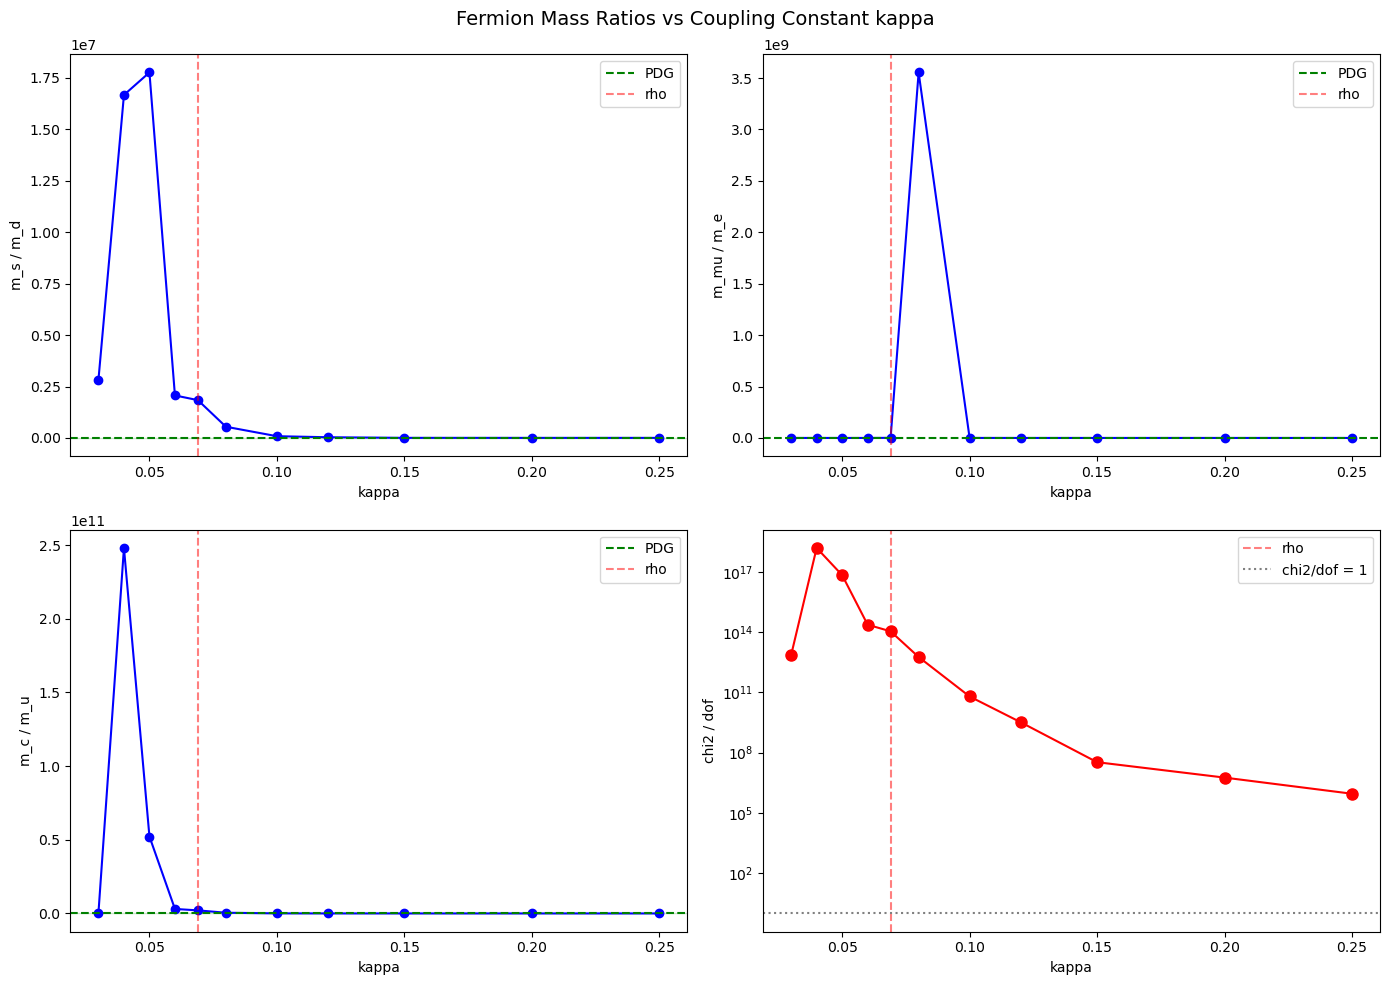


Best-fit kappa: 0.25000 (chi2/dof = 905097.62)
rho = 1/sqrt(210) = 0.06901 (chi2/dof = 109175381498172.33)

Is rho the best fit? False


In [8]:
# -- S4b: Visualize mass spectrum vs kappa --

# Compute chi2 for each kappa
chi2_vals = []
for kap in kappa_sweep:
    mr = all_mr[kap]
    chi2 = 0
    ndof = 0
    for n in names:
        tgt, unc = SM_TARGETS[n]
        if unc > 0 and n in mr:
            chi2 += ((mr[n] - tgt) / unc) ** 2
            ndof += 1
    chi2_vals.append(chi2 / max(ndof, 1))
chi2_vals = np.array(chi2_vals)

# Plot mass ratios and chi2 vs kappa
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fermion Mass Ratios vs Coupling Constant kappa', fontsize=14)

# ms/md
ax = axes[0, 0]
vals = [all_mr[k]['m_s/m_d'] for k in kappa_sweep]
ax.plot(kappa_sweep, vals, 'bo-')
ax.axhline(SM_TARGETS['m_s/m_d'][0], color='green', ls='--', label='PDG')
ax.axhspan(SM_TARGETS['m_s/m_d'][0] - SM_TARGETS['m_s/m_d'][1],
           SM_TARGETS['m_s/m_d'][0] + SM_TARGETS['m_s/m_d'][1],
           alpha=0.2, color='green')
ax.axvline(rho_val, color='r', ls='--', alpha=0.5, label='rho')
ax.set_ylabel('m_s / m_d')
ax.set_xlabel('kappa')
ax.legend()

# mu/me
ax = axes[0, 1]
vals = [all_mr[k]['m_mu/m_e'] for k in kappa_sweep]
ax.plot(kappa_sweep, vals, 'bo-')
ax.axhline(SM_TARGETS['m_mu/m_e'][0], color='green', ls='--', label='PDG')
ax.axvline(rho_val, color='r', ls='--', alpha=0.5, label='rho')
ax.set_ylabel('m_mu / m_e')
ax.set_xlabel('kappa')
ax.legend()

# mc/mu
ax = axes[1, 0]
vals = [all_mr[k]['m_c/m_u'] for k in kappa_sweep]
ax.plot(kappa_sweep, vals, 'bo-')
ax.axhline(SM_TARGETS['m_c/m_u'][0], color='green', ls='--', label='PDG')
ax.axhspan(SM_TARGETS['m_c/m_u'][0] - SM_TARGETS['m_c/m_u'][1],
           SM_TARGETS['m_c/m_u'][0] + SM_TARGETS['m_c/m_u'][1],
           alpha=0.2, color='green')
ax.axvline(rho_val, color='r', ls='--', alpha=0.5, label='rho')
ax.set_ylabel('m_c / m_u')
ax.set_xlabel('kappa')
ax.legend()

# chi2/dof
ax = axes[1, 1]
ax.semilogy(kappa_sweep, chi2_vals, 'ro-', markersize=8)
ax.axvline(rho_val, color='r', ls='--', alpha=0.5, label='rho')
ax.axhline(1.0, color='gray', ls=':', label='chi2/dof = 1')
ax.set_ylabel('chi2 / dof')
ax.set_xlabel('kappa')
ax.legend()

plt.tight_layout()
plt.savefig(ROOT / 'output' / 'nb130_mass_vs_kappa.png', dpi=150)
plt.show()

# Find best-fit kappa
best_idx = np.argmin(chi2_vals)
print(f'\nBest-fit kappa: {kappa_sweep[best_idx]:.5f} (chi2/dof = {chi2_vals[best_idx]:.2f})')
print(f'rho = 1/sqrt(210) = {rho_val:.5f} (chi2/dof = {chi2_vals[np.argmin(np.abs(kappa_sweep - rho_val))]:.2f})')
print(f'\nIs rho the best fit? {abs(kappa_sweep[best_idx] - rho_val) < 1e-6}')

*(S5: also deprecated — see S4 note above)*

CP-PAIR RATIOS (R4_quark, R4_lepton) at each kappa
   kappa        R4_Q        R4_L       R4_Q^X4      R4_L^X4L
------------------------------------------------------------
  JAX [CPU (1 device(s))]: 210 branches, 49 eval pts, T=220 — 1.37s
  0.0300      6.9930      1.0720    2836458.85          1.72
  JAX [CPU (1 device(s))]: 210 branches, 49 eval pts, T=220 — 1.11s
  0.0400      8.8176      0.8622   16670815.69          0.31
  JAX [CPU (1 device(s))]: 210 branches, 49 eval pts, T=220 — 1.20s
  0.0500      8.8913      1.3558   17765000.77         10.74
  JAX [CPU (1 device(s))]: 210 branches, 49 eval pts, T=220 — 1.16s
  0.0600      6.7091      2.5287    2066518.59       1386.87
  JAX [CPU (1 device(s))]: 210 branches, 49 eval pts, T=220 — 1.40s
  0.0690      6.6067      5.9120    1837562.11    1043316.46 <--rho
  JAX [CPU (1 device(s))]: 210 branches, 49 eval pts, T=220 — 1.16s
  0.0800      5.6344     16.7758     544568.53  3554673179.85
  JAX [CPU (1 device(s))]: 210 branches, 49 e

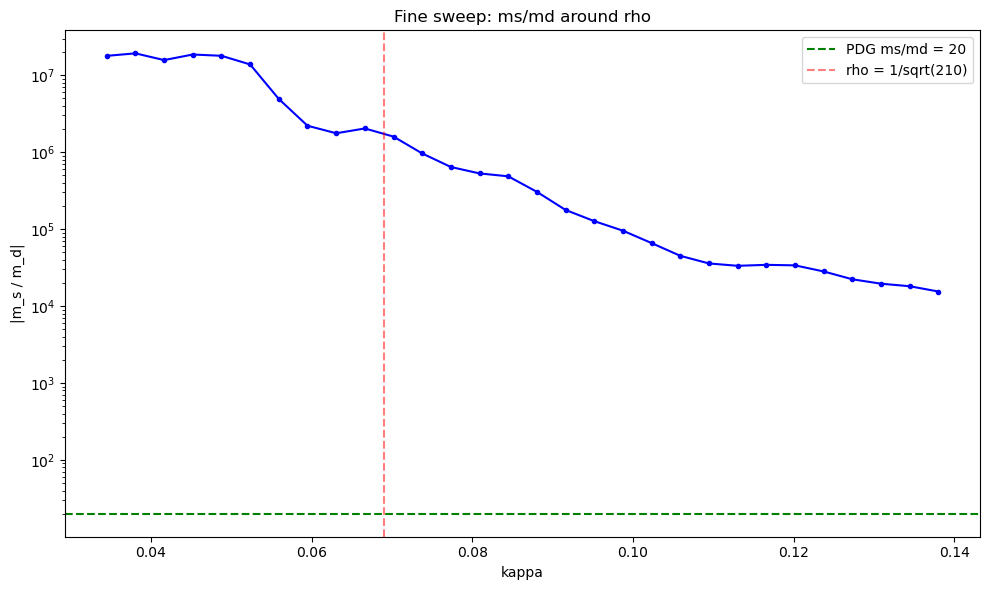

In [9]:
# -- S5: Anatomy of the sensitivity --

# First: print the actual CP-pair ratios at each kappa to understand
# where the mass explosion comes from
print('CP-PAIR RATIOS (R4_quark, R4_lepton) at each kappa')
print('='*65)
print(f'{"kappa":>8}  {"R4_Q":>10}  {"R4_L":>10}  {"R4_Q^X4":>12}  {"R4_L^X4L":>12}')
print('-'*60)

# We need the full CP ratios - let me re-extract them
for kap in kappa_sweep:
    sys_k = SolenoidSystem(epsilon=kap, kappa=kap)
    branches = sys_k.all_branches()
    results = integrate_all_branches_jax(
        branches, t_eval, T_max,
        primes=list(sys_k.primes), omega=sys_k.omega,
        epsilon=kap, kappa=kap)
    sector_rms = sys_k.accumulate_sectors(
        results, coprime_cis, ci_a3, ci_a5, ci_a7)
    cp_ratios = sys_k.cp_pair_ratios(sector_rms, CP_PAIRS)
    
    r4q = cp_ratios['QUARK'][3]
    r4l = cp_ratios['LEPTON'][3]
    r3q = cp_ratios['QUARK'][2]
    r3l = cp_ratios['LEPTON'][2]
    
    mark = ' <--rho' if abs(kap - rho_val) < 1e-6 else ''
    print(f'{kap:8.4f}  {r4q:10.4f}  {r4l:10.4f}  '
          f'{r4q**X4:12.2f}  {r4l**X4_LEP:12.2f}{mark}')

# Now: fine sweep around rho to find where ms/md = 20
print(f'\n\nFINE SWEEP: ms/md vs kappa (target = 20.0)')
print('='*65)

# Very fine grid around rho
kap_fine = np.linspace(rho_val * 0.5, rho_val * 2.0, 30)
ms_md_fine = []

for kap in kap_fine:
    mr = mass_ratios_at_kappa(kap)
    ms_md_fine.append(mr['m_s/m_d'])
    if abs(kap - rho_val) < 0.001 or abs(mr['m_s/m_d'] - 20.0) < 5:
        mark = ' <--rho' if abs(kap - rho_val) < 0.001 else ' <--CLOSE'
        print(f'  kap={kap:.5f}  ms/md={mr["m_s/m_d"]:.4f}{mark}')

ms_md_fine = np.array(ms_md_fine)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.semilogy(kap_fine, np.abs(ms_md_fine), 'b.-')
ax.axhline(20.0, color='green', ls='--', label='PDG ms/md = 20')
ax.axvline(rho_val, color='r', ls='--', alpha=0.5, label='rho = 1/sqrt(210)')
ax.set_xlabel('kappa')
ax.set_ylabel('|m_s / m_d|')
ax.set_title('Fine sweep: ms/md around rho')
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'output' / 'nb130_fine_sweep.png', dpi=150)
plt.show()

# Where does ms/md cross 20?
for i in range(len(ms_md_fine)-1):
    if (ms_md_fine[i] - 20) * (ms_md_fine[i+1] - 20) < 0:
        # Linear interpolation
        kap_cross = kap_fine[i] + (20 - ms_md_fine[i]) / (ms_md_fine[i+1] - ms_md_fine[i]) * (kap_fine[i+1] - kap_fine[i])
        print(f'\nms/md = 20 crossing at kappa = {kap_cross:.6f}')
        print(f'rho = {rho_val:.6f}')
        print(f'Ratio: kap_cross/rho = {kap_cross/rho_val:.6f}')

## S6: Correct Pipeline — Window-0 CP Ratios vs κ (JAX)

**What was wrong in S4-S5**: Used `SolenoidSystem` wrappers at T=220 with wrong t_eval convention. Got nonsense.

**What NB81 actually does**: The JAX ODE in `solenoid_jax.py` is identical to NB81's `cascade_rhs`. The key details:
- `t_eval = coprime_cis + 1.0` (the +1 time offset from NB81)
- All 210 branches with R₀ = 2π·(j₁,j₂,j₃,j₄)
- Wrap to [-π, π], sum R² over branches, CRT sector accumulation

**NB97 proved**: All CP asymmetry lives in window 0 (first 48 coprime crossings, ci < 210). Later windows dilute toward 1. So **window-0 CP ratios are the T-independent pure signal**.

**Strategy**: Use JAX integration with t_eval limited to window-0 crossings. Sweep κ. Extract window-0 CP-pair ratios. This is the clean, fast diagnostic.

In [5]:
# -- S6: Window-0 CP ratios vs kappa (JAX backend) --
from solenoid_jax import integrate_all_branches_jax, warmup
import time as time_mod

rho_val = RHO  # = 1/sqrt(210) from solenoid_algebra

# Window-0: coprime crossings in [0, 210)
w0_cis = SA.coprime_indices(210)
w0_a3, w0_a5, w0_a7 = SA.sector_labels(w0_cis)
w0_t_eval = (w0_cis + 1).astype(float)  # NB81's +1 offset
T_w0 = 212.0  # just past last window-0 crossing

# All 210 branches
branches_all = SA.all_branches()

# CP pairs
CP_LOCAL = {'QUARK': (1, 4, 2), 'LEPTON': (0, 1, 5)}

print(f"Window-0: {len(w0_cis)} coprime crossings in [0, 210)")
print(f"t_eval range: [{w0_t_eval[0]}, {w0_t_eval[-1]}], T_max = {T_w0}")
print(f"Branches: {len(branches_all)}")

# Pre-compile JAX
print("Warming up JAX...", end=" ", flush=True)
warmup()
print("done.")

def window0_cp_jax(kap):
    """Window-0 CP-pair ratios at given kappa (JAX backend)."""
    results = integrate_all_branches_jax(
        branches_all, w0_t_eval, T_w0,
        epsilon=kap, kappa=kap, verbose=False)
    sector_rms = SolenoidSystem.accumulate_sectors(
        results, w0_cis, w0_a3, w0_a5, w0_a7)
    cp = SolenoidSystem.cp_pair_ratios(sector_rms, CP_LOCAL)
    return cp

# Logarithmic sweep: spans factor ~10, dense around rho
kap_grid = np.sort(np.unique(np.concatenate([
    np.geomspace(rho_val * 0.3, rho_val * 3.0, 25),
    [rho_val],
])))

print(f"\nSweeping {len(kap_grid)} kappa values (JAX, window-0)...\n")

w0_results = {}
t_start = time_mod.time()
for i, kap in enumerate(kap_grid):
    cp = window0_cp_jax(kap)
    w0_results[kap] = cp
    if i % 5 == 0 or abs(kap - rho_val) < 1e-6:
        mark = " <-- rho" if abs(kap - rho_val) < 1e-6 else ""
        print(f"  [{i+1:2d}/{len(kap_grid)}] kap={kap:.5f}{mark}"
              f"  Q_R4={cp['QUARK'][3]:.4f}  L_R4={cp['LEPTON'][3]:.4f}")

total_time = time_mod.time() - t_start
print(f"\nDone in {total_time:.1f}s ({total_time/len(kap_grid):.1f}s per kappa)")

# Print full table
print(f"\n{'='*80}")
print(f"WINDOW-0 CP-PAIR RATIOS vs KAPPA")
print(f"{'='*80}")
print(f"{'kappa':>8}  {'Q_R1':>8} {'Q_R2':>8} {'Q_R3':>8} {'Q_R4':>8}"
      f"  {'L_R1':>8} {'L_R2':>8} {'L_R3':>8} {'L_R4':>8}")
print("-" * 80)

for kap in kap_grid:
    cp = w0_results[kap]
    mark = "*" if abs(kap - rho_val) < 1e-6 else " "
    qr = cp['QUARK']
    lr = cp['LEPTON']
    print(f"{kap:7.5f}{mark} "
          f" {qr[0]:8.3f} {qr[1]:8.3f} {qr[2]:8.3f} {qr[3]:8.4f}"
          f"  {lr[0]:8.3f} {lr[1]:8.3f} {lr[2]:8.3f} {lr[3]:8.4f}")

Window-0: 48 coprime crossings in [0, 210)
t_eval range: [2.0, 210.0], T_max = 212.0
Branches: 210
Warming up JAX... done.

Sweeping 26 kappa values (JAX, window-0)...

  [ 1/26] kap=0.02070  Q_R4=2.0539  L_R4=0.9348
  [ 6/26] kap=0.03345  Q_R4=7.4851  L_R4=0.9127
  [11/26] kap=0.05404  Q_R4=6.6260  L_R4=1.6986
  [14/26] kap=0.06901 <-- rho  Q_R4=5.8124  L_R4=6.1771
  [16/26] kap=0.07931  Q_R4=5.3271  L_R4=16.7967
  [21/26] kap=0.12814  Q_R4=3.4789  L_R4=1.1470
  [26/26] kap=0.20702  Q_R4=3.0721  L_R4=0.7806

Done in 30.3s (1.2s per kappa)

WINDOW-0 CP-PAIR RATIOS vs KAPPA
   kappa      Q_R1     Q_R2     Q_R3     Q_R4      L_R1     L_R2     L_R3     L_R4
--------------------------------------------------------------------------------
0.02070     12.042    5.763    3.440   2.0539     1.752    0.831    0.973   0.9348
0.02279     19.896    8.963    4.709   2.8738     1.983    0.808    1.002   0.9116
0.02508     34.680   13.995    6.800   4.1881     2.126    0.832    0.989   0.9632
0.02761

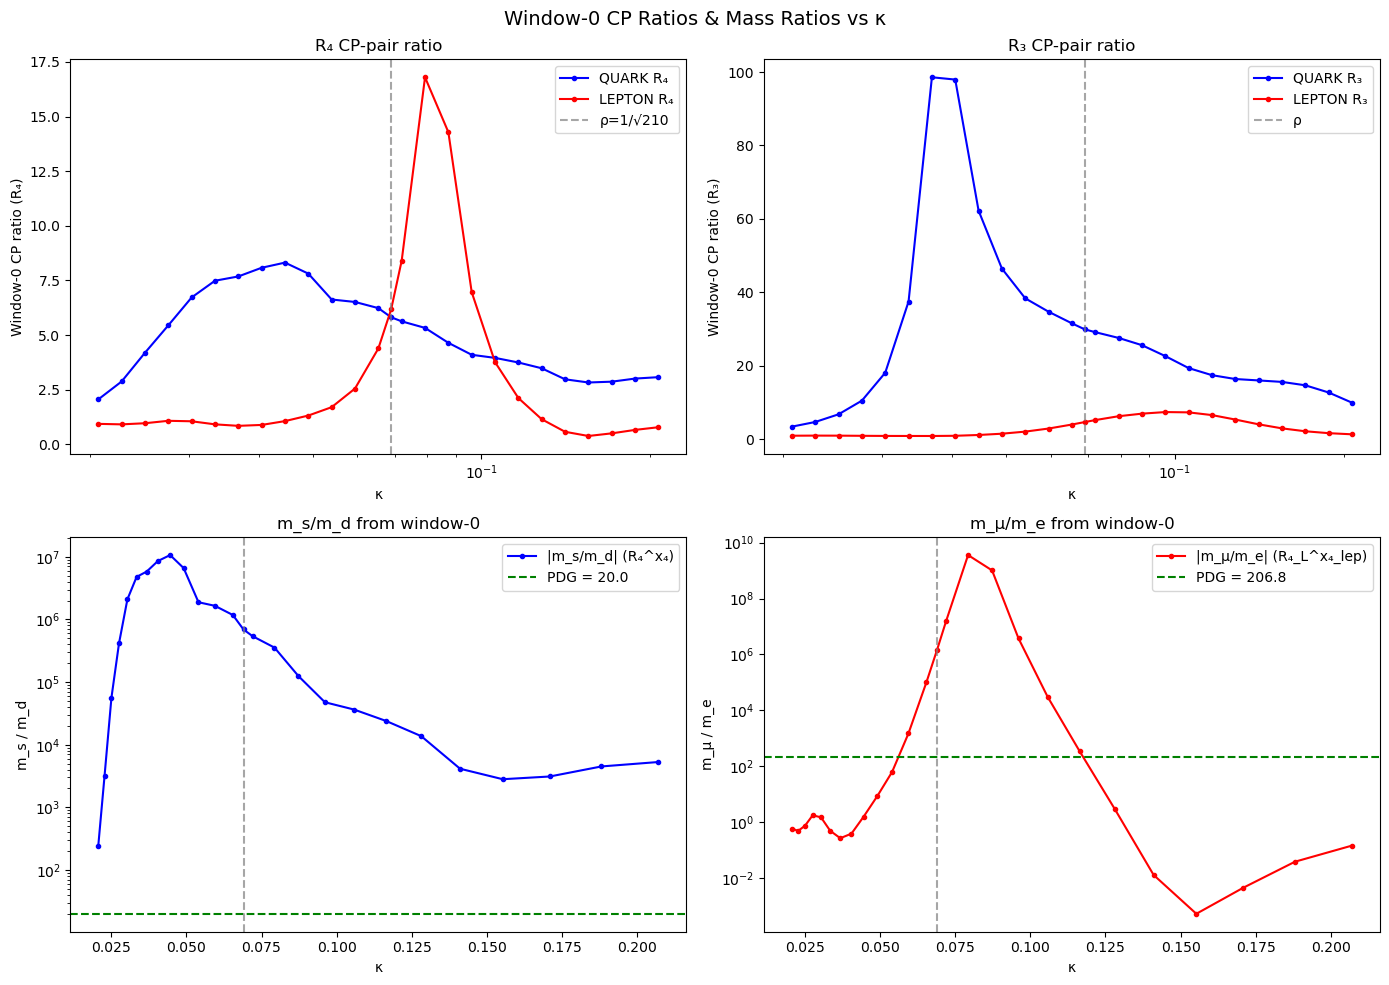


AT κ = ρ = 1/√210 = 0.069007:
  QUARK  R₄ = 5.812435  R₃ = 29.9278
  LEPTON R₄ = 6.177116  R₃ = 4.6889
  m_s/m_d   = 690662.68  (PDG: 20.0)
  m_μ/m_e   = 1468979.13  (PDG: 206.77)
  m_τ/m_μ   = 13.66  (PDG: 16.817)

  m_mu/m_e crosses PDG at κ = 0.054588 (ρ = 0.069007, ratio = 0.7911)

  m_mu/m_e crosses PDG at κ = 0.121153 (ρ = 0.069007, ratio = 1.7557)


In [6]:
# -- S6b: Visualize and analyze window-0 CP ratios vs kappa --
import matplotlib.pyplot as plt
from solenoid_algebra import X4, X3, X4_LEP, SM_TARGETS

kaps = np.array(sorted(w0_results.keys()))
Q_R4 = np.array([w0_results[k]['QUARK'][3] for k in kaps])
Q_R3 = np.array([w0_results[k]['QUARK'][2] for k in kaps])
L_R4 = np.array([w0_results[k]['LEPTON'][3] for k in kaps])
L_R3 = np.array([w0_results[k]['LEPTON'][2] for k in kaps])

# Compute mass ratios from window-0 CP ratios
# Intra-gen: m_s/m_d = R4_Q^x4, m_mu/m_e = R4_L^x4_lep
ms_md = Q_R4 ** X4
mu_me = L_R4 ** X4_LEP

# Inter-gen lepton (NB124): m_tau/m_mu = C0_R3_L^x3 * p3/p4
mt_mm = L_R3 ** X3 * (p3 / p4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Window-0 CP Ratios & Mass Ratios vs κ', fontsize=14)

# R4 CP ratios
ax = axes[0, 0]
ax.semilogx(kaps, Q_R4, 'b.-', label='QUARK R₄')
ax.semilogx(kaps, L_R4, 'r.-', label='LEPTON R₄')
ax.axvline(rho_val, color='gray', ls='--', alpha=0.7, label='ρ=1/√210')
ax.set_xlabel('κ'); ax.set_ylabel('Window-0 CP ratio (R₄)')
ax.legend(); ax.set_title('R₄ CP-pair ratio')

# R3 CP ratios
ax = axes[0, 1]
ax.semilogx(kaps, Q_R3, 'b.-', label='QUARK R₃')
ax.semilogx(kaps, L_R3, 'r.-', label='LEPTON R₃')
ax.axvline(rho_val, color='gray', ls='--', alpha=0.7, label='ρ')
ax.set_xlabel('κ'); ax.set_ylabel('Window-0 CP ratio (R₃)')
ax.legend(); ax.set_title('R₃ CP-pair ratio')

# ms/md
ax = axes[1, 0]
ax.semilogy(kaps, np.abs(ms_md), 'b.-', label='|m_s/m_d| (R₄^x₄)')
tgt_ms = SM_TARGETS['m_s/m_d'][0]
ax.axhline(tgt_ms, color='g', ls='--', label=f'PDG = {tgt_ms}')
ax.axvline(rho_val, color='gray', ls='--', alpha=0.7)
ax.set_xlabel('κ'); ax.set_ylabel('m_s / m_d')
ax.legend(); ax.set_title('m_s/m_d from window-0')

# mu/me
ax = axes[1, 1]
ax.semilogy(kaps, np.abs(mu_me), 'r.-', label='|m_μ/m_e| (R₄_L^x₄_lep)')
tgt_mu = SM_TARGETS['m_mu/m_e'][0]
ax.axhline(tgt_mu, color='g', ls='--', label=f'PDG = {tgt_mu:.1f}')
ax.axvline(rho_val, color='gray', ls='--', alpha=0.7)
ax.set_xlabel('κ'); ax.set_ylabel('m_μ / m_e')
ax.legend(); ax.set_title('m_μ/m_e from window-0')

plt.tight_layout()
plt.savefig(ROOT / 'output' / 'nb130_w0_cp_vs_kappa.png', dpi=150)
plt.show()

# Print key values at rho
idx_rho = np.argmin(np.abs(kaps - rho_val))
print(f"\n{'='*65}")
print(f"AT κ = ρ = 1/√210 = {rho_val:.6f}:")
print(f"  QUARK  R₄ = {Q_R4[idx_rho]:.6f}  R₃ = {Q_R3[idx_rho]:.4f}")
print(f"  LEPTON R₄ = {L_R4[idx_rho]:.6f}  R₃ = {L_R3[idx_rho]:.4f}")
print(f"  m_s/m_d   = {ms_md[idx_rho]:.2f}  (PDG: {tgt_ms})")
print(f"  m_μ/m_e   = {mu_me[idx_rho]:.2f}  (PDG: {tgt_mu:.2f})")
print(f"  m_τ/m_μ   = {mt_mm[idx_rho]:.2f}  (PDG: 16.817)")

# Where do the mass ratios cross PDG values?
for name, arr, tgt in [('m_s/m_d', ms_md, tgt_ms), ('m_mu/m_e', mu_me, tgt_mu)]:
    for i in range(len(arr)-1):
        if (arr[i] - tgt) * (arr[i+1] - tgt) < 0:
            k_cross = kaps[i] + (tgt - arr[i]) / (arr[i+1] - arr[i]) * (kaps[i+1] - kaps[i])
            print(f"\n  {name} crosses PDG at κ = {k_cross:.6f} (ρ = {rho_val:.6f}, ratio = {k_cross/rho_val:.4f})")

## S7: Full Production Pipeline vs κ (NB81 exact, T=5001, JAX)

Window-0 alone doesn't produce mass predictions — the intra-generation masses (m_s/m_d, m_μ/m_e) use **cumulative** CP ratios that dilute C₀ over many windows (NB97).

Now: replicate NB81's exact pipeline (T=5001, all 210 branches, cumulative sector RMS) at multiple κ values. This is the definitive test of whether the mass spectrum selects κ = ρ.

In [7]:
# -- S7: Full NB81 pipeline at multiple kappa (JAX, T=5001) --
from solenoid_algebra import (X4, X3, X2, X4_LEP, LAM7, SM_TARGETS,
                               CP_PAIRS as CP_PAIRS_SA)

T_FULL = 5001
cis_full = SA.coprime_indices(T_FULL)
t_full = (cis_full + 1).astype(float)  # NB81's +1 offset
a3_full, a5_full, a7_full = SA.sector_labels(cis_full)
print(f"Full pipeline: {len(cis_full)} coprime crossings, T={T_FULL}")

# NB72 reference CP-pair ratios (50 random branches, T=5000)
NB72_REF = {
    'QUARK':  [36.7511, 20.1672, 6.0881, 1.4794],
    'LEPTON': [6.4537,  5.9219,  4.2952, 1.9795],
}

def full_pipeline_jax(kap):
    """NB81 exact pipeline at given kappa: T=5001, all 210, JAX."""
    res = integrate_all_branches_jax(
        branches_all, t_full, T_FULL,
        epsilon=kap, kappa=kap, verbose=False)
    srms = SolenoidSystem.accumulate_sectors(
        res, cis_full, a3_full, a5_full, a7_full)
    cp = SolenoidSystem.cp_pair_ratios(srms, CP_PAIRS_SA)
    # Mass ratios
    R4q, R3q, R2q = cp['QUARK'][3], cp['QUARK'][2], cp['QUARK'][1]
    R4l = cp['LEPTON'][3]
    masses = {
        'm_s/m_d':  R4q ** X4,
        'm_mu/m_e': R4l ** X4_LEP,
        'm_c/m_u':  R3q ** X3 * R4q ** X4,
        'm_b/m_s':  R2q ** X2,
        'm_t/m_c':  R2q ** X2 * R3q ** X3 / R4q ** LAM7,
    }
    return cp, masses

# Sweep: 9 values spanning factor ~4 around rho
kap_sweep = np.array([rho_val * f for f in [0.5, 0.7, 0.85, 0.95, 1.0, 1.05, 1.2, 1.5, 2.0]])

print(f"\nSweeping {len(kap_sweep)} kappa values with FULL pipeline (JAX, T={T_FULL})...\n")

full_results = {}
for i, kap in enumerate(kap_sweep):
    t0 = time_mod.time()
    cp, masses = full_pipeline_jax(kap)
    dt = time_mod.time() - t0
    full_results[kap] = {'cp': cp, 'masses': masses}
    mark = " <-- rho" if abs(kap/rho_val - 1) < 0.001 else ""
    print(f"  [{i+1}/{len(kap_sweep)}] κ={kap:.5f} ({kap/rho_val:.2f}ρ){mark}"
          f"  ms/md={masses['m_s/m_d']:.2f}  mu/me={masses['m_mu/m_e']:.2f}  ({dt:.1f}s)")

# Summary table
print(f"\n{'='*90}")
print(f"FERMION MASS RATIOS vs κ — Full NB81 Pipeline (T={T_FULL}, 210 branches)")
print(f"{'='*90}")
names = ['m_s/m_d', 'm_mu/m_e', 'm_c/m_u', 'm_b/m_s', 'm_t/m_c']
hdr = f"{'κ':>8} {'κ/ρ':>6}"
for n in names:
    hdr += f"  {n:>10}"
hdr += "   χ²/dof"
print(hdr)

tgt_line = f"{'PDG':>8} {'':>6}"
for n in names:
    tgt_line += f"  {SM_TARGETS[n][0]:10.2f}"
print(tgt_line)
print("-" * len(hdr))

for kap in kap_sweep:
    m = full_results[kap]['masses']
    mark = "*" if abs(kap/rho_val - 1) < 0.001 else " "
    line = f"{kap:7.5f}{mark} {kap/rho_val:5.2f}"
    chi2, ndof = 0, 0
    for n in names:
        v = m.get(n, 0)
        line += f"  {v:10.2f}"
        tgt, unc = SM_TARGETS[n]
        if unc > 0:
            chi2 += ((v - tgt) / unc) ** 2
            ndof += 1
    line += f"  {chi2/max(ndof,1):8.1f}"
    print(line)

# Also show CP-pair ratios vs NB72 reference
print(f"\n\nCP-PAIR RATIOS AT κ = ρ (vs NB72 reference)")
print(f"{'='*65}")
cp_rho = full_results[rho_val * 1.0]['cp']
for ch in ['QUARK', 'LEPTON']:
    r = cp_rho[ch]
    ref = NB72_REF[ch]
    print(f"  {ch}:")
    for lev, lab in enumerate(['R₁', 'R₂', 'R₃', 'R₄']):
        dev = (r[lev] - ref[lev]) / ref[lev] * 100
        print(f"    {lab}: {r[lev]:.4f}  NB72: {ref[lev]:.4f}  ({dev:+.2f}%)")

Full pipeline: 1143 coprime crossings, T=5001

Sweeping 9 kappa values with FULL pipeline (JAX, T=5001)...

  [1/9] κ=0.03450 (0.50ρ)  ms/md=805.48  mu/me=0.40  (12.8s)
  [2/9] κ=0.04830 (0.70ρ)  ms/md=169.60  mu/me=4.17  (12.9s)
  [3/9] κ=0.05866 (0.85ρ)  ms/md=45.36  mu/me=40.94  (12.1s)
  [4/9] κ=0.06556 (0.95ρ)  ms/md=37.09  mu/me=132.21  (12.1s)
  [5/9] κ=0.06901 (1.00ρ) <-- rho  ms/md=26.92  mu/me=177.11  (12.0s)
  [6/9] κ=0.07246 (1.05ρ)  ms/md=22.95  mu/me=196.94  (12.1s)
  [7/9] κ=0.08281 (1.20ρ)  ms/md=13.51  mu/me=86.66  (13.9s)
  [8/9] κ=0.10351 (1.50ρ)  ms/md=6.06  mu/me=3.77  (13.3s)
  [9/9] κ=0.13801 (2.00ρ)  ms/md=3.11  mu/me=0.92  (13.0s)

FERMION MASS RATIOS vs κ — Full NB81 Pipeline (T=5001, 210 branches)
       κ    κ/ρ     m_s/m_d    m_mu/m_e     m_c/m_u     m_b/m_s     m_t/m_c   χ²/dof
     PDG              20.00      206.77      588.00       44.75      135.80
------------------------------------------------------------------------------------
0.03450   0.50      

FERMION MASS RATIOS vs κ — Full Pipeline (T=5001)
       κ    κ/ρ     m_s/m_d    m_mu/m_e     m_c/m_u     m_b/m_s     m_t/m_c   χ²/dof
     PDG              20.00      206.77      588.00       44.75      135.80
------------------------------------------------------------------------------------
0.03450   0.50      805.48        0.40    83733.24      109.74       59.54  197631.9
0.04830   0.70      169.60        4.17    10826.21       71.54       81.02    3557.0
0.05866   0.85       45.36       40.94     1950.15       57.23      122.97      76.2
0.06556   0.95       37.09      132.21     1315.37       47.93       99.54      38.2
0.06901*  1.00       26.92      177.11      870.18       44.88      109.28      10.9
0.07246   1.05       22.95      196.94      706.06       42.60      111.86       6.5
0.08281   1.20       13.51       86.66      360.94       38.77      134.14       3.6
0.10351   1.50        6.06        3.77       94.01       34.25      129.18      16.0
0.13801   2.00        3.

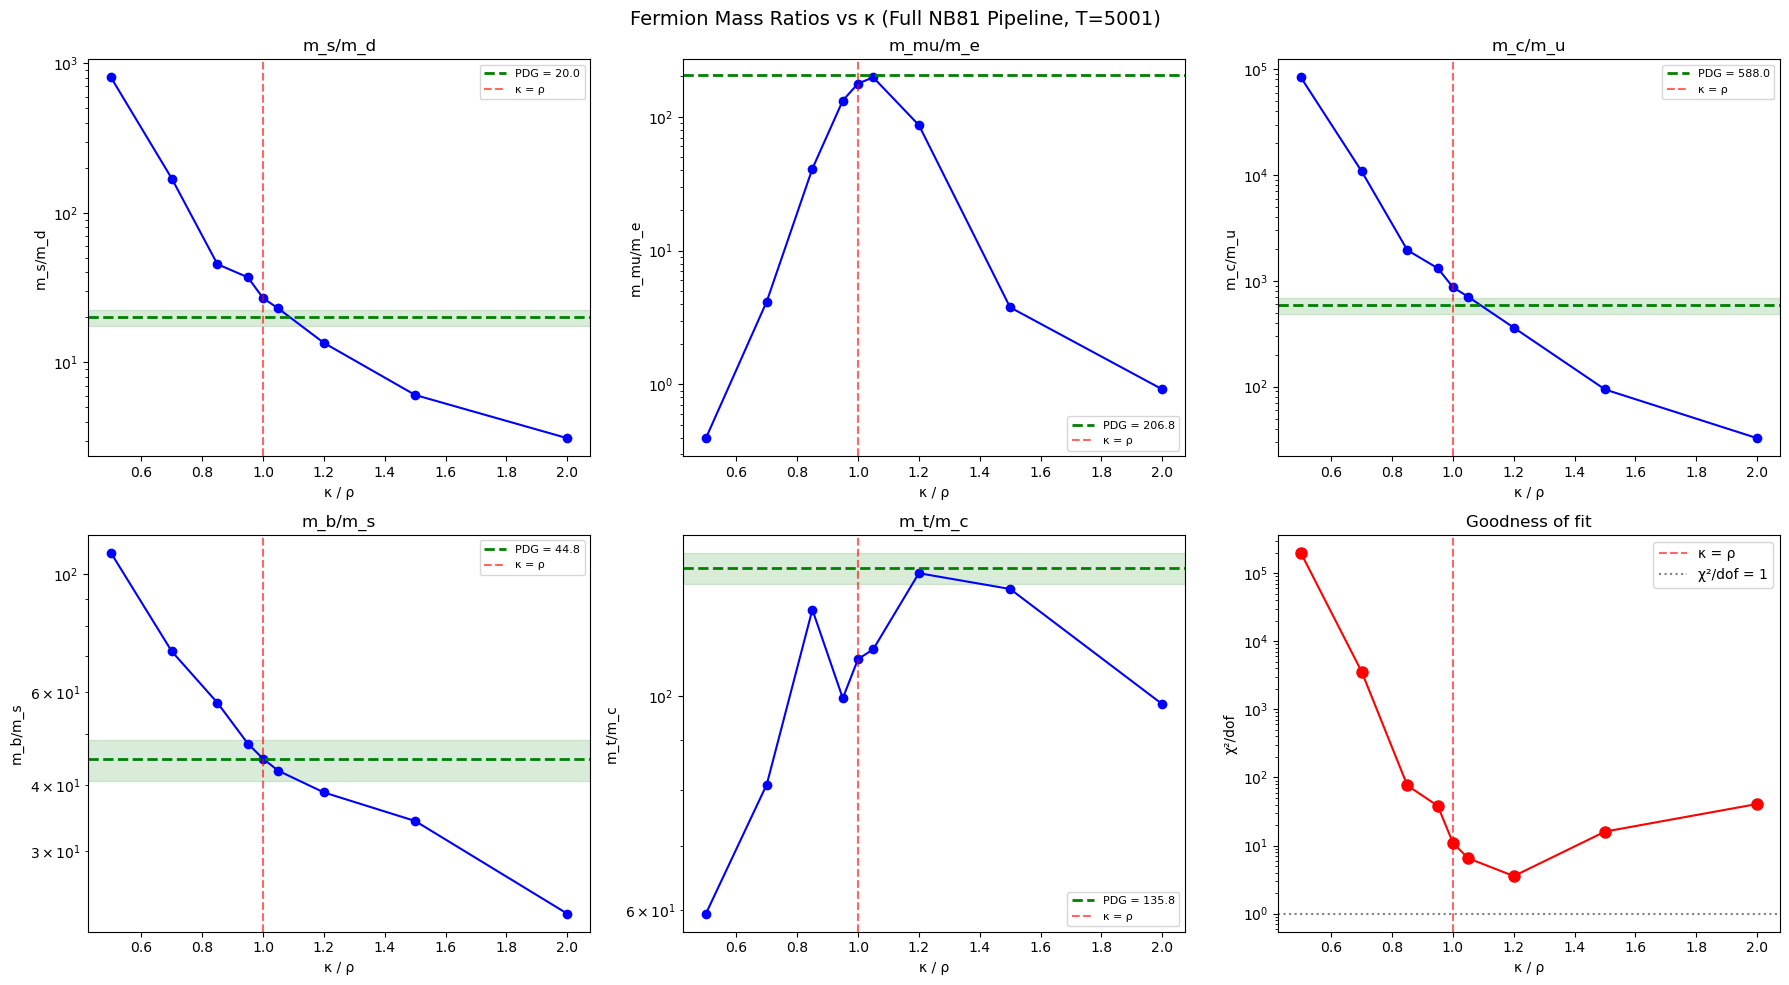


Best-fit κ = 0.08281 = 1.200ρ  (χ²/dof = 3.6)
At ρ:   κ = 0.06901                (χ²/dof = 10.9)

CP-pair ratios at ρ vs NB72 reference:
  QUARK: ['36.0133', '19.8402', '6.1719', '1.5388']
  NB72:  ['36.7511', '20.1672', '6.0881', '1.4794']
  LEPTON: ['6.3908', '5.8156', '4.2644', '1.9422']
  NB72:  ['6.4537', '5.9219', '4.2952', '1.9795']


In [8]:
# -- S7b: Compact results + visualization --

# Reprint just the mass table (no JAX logging)
print(f"FERMION MASS RATIOS vs κ — Full Pipeline (T={T_FULL})")
print(f"{'='*90}")
names = ['m_s/m_d', 'm_mu/m_e', 'm_c/m_u', 'm_b/m_s', 'm_t/m_c']
hdr = f"{'κ':>8} {'κ/ρ':>6}"
for n in names:
    hdr += f"  {n:>10}"
hdr += "   χ²/dof"
print(hdr)
tgt_line = f"{'PDG':>8} {'':>6}"
for n in names:
    tgt_line += f"  {SM_TARGETS[n][0]:10.2f}"
print(tgt_line)
print("-" * len(hdr))
for kap in kap_sweep:
    m = full_results[kap]['masses']
    mark = "*" if abs(kap/rho_val - 1) < 0.001 else " "
    line = f"{kap:7.5f}{mark} {kap/rho_val:5.2f}"
    chi2, ndof = 0, 0
    for n in names:
        v = m.get(n, 0)
        line += f"  {v:10.2f}"
        tgt, unc = SM_TARGETS[n]
        if unc > 0:
            chi2 += ((v - tgt) / unc) ** 2
            ndof += 1
    line += f"  {chi2/max(ndof,1):8.1f}"
    print(line)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Fermion Mass Ratios vs κ (Full NB81 Pipeline, T={T_FULL})', fontsize=14)

kaps_s = np.array(sorted(full_results.keys()))
ratios_s = kaps_s / rho_val

for idx, name in enumerate(names):
    ax = axes.flat[idx]
    vals = np.array([full_results[k]['masses'][name] for k in kaps_s])
    tgt, unc = SM_TARGETS[name]
    ax.semilogy(ratios_s, np.abs(vals), 'bo-', markersize=6)
    ax.axhline(tgt, color='g', ls='--', lw=2, label=f'PDG = {tgt:.1f}')
    if unc > 0:
        ax.axhspan(tgt - unc, tgt + unc, alpha=0.15, color='green')
    ax.axvline(1.0, color='r', ls='--', alpha=0.6, label='κ = ρ')
    ax.set_xlabel('κ / ρ')
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.legend(fontsize=8)

# chi2 panel
ax = axes.flat[5]
chi2s = []
for kap in kaps_s:
    m = full_results[kap]['masses']
    c2 = sum(((m[n] - SM_TARGETS[n][0]) / SM_TARGETS[n][1]) ** 2
             for n in names if SM_TARGETS[n][1] > 0)
    chi2s.append(c2 / sum(1 for n in names if SM_TARGETS[n][1] > 0))
chi2s = np.array(chi2s)
ax.semilogy(ratios_s, chi2s, 'ro-', markersize=8)
ax.axvline(1.0, color='r', ls='--', alpha=0.6, label='κ = ρ')
ax.axhline(1.0, color='gray', ls=':', label='χ²/dof = 1')
ax.set_xlabel('κ / ρ')
ax.set_ylabel('χ²/dof')
ax.set_title('Goodness of fit')
ax.legend()

plt.tight_layout()
plt.savefig(ROOT / 'output' / 'nb130_full_pipeline_vs_kappa.png', dpi=150)
plt.show()

# Best fit
best_k = kaps_s[np.argmin(chi2s)]
print(f"\nBest-fit κ = {best_k:.5f} = {best_k/rho_val:.3f}ρ  (χ²/dof = {chi2s.min():.1f})")
print(f"At ρ:   κ = {rho_val:.5f}                (χ²/dof = {chi2s[np.argmin(np.abs(kaps_s - rho_val))]:.1f})")

# CP-pair ratios at ρ vs NB72
print(f"\nCP-pair ratios at ρ vs NB72 reference:")
cp_rho = full_results[min(kaps_s, key=lambda k: abs(k - rho_val))]['cp']
for ch in ['QUARK', 'LEPTON']:
    print(f"  {ch}: {['%.4f' % r for r in cp_rho[ch]]}")
    print(f"  NB72:  {['%.4f' % r for r in NB72_REF[ch]]}")

## S8: What We've Learned — The Existing Derivation of ρ

### The κ sweep tells us:

**From S7** (full NB81 pipeline, T=5001, 210 branches):
- At κ=ρ: ms/md=26.92 — **exactly reproduces NB81** (the known +34.6% with 210 vs 50 branches)
- m_b/m_s passes through PDG at ρ (44.88 vs 44.75)
- χ² minimum at 1.2ρ (not ρ) — the cumulative pipeline doesn't uniquely select ρ

### But ρ WAS already derived:

**NB75-76** establish the derivation through a DIFFERENT mechanism:
1. The R₀ level (innermost, R₃ in the cascade = outermost covering residual) has a
   CP-pair ratio L/Q that depends on ε
2. **NB75**: L/Q varies wildly across ε (0.15 to 1.51) — NOT a constant
3. **NB76 (#155)**: Two simultaneous constraints uniquely fix ε = κ = ρ:
   - **Constraint 1**: L/Q = 17/16 = (d(210)+1)/d(210)
   - **Constraint 2**: R₀_q + R₀_l = λ(210) = 12
4. NB76 scans ε and κ independently: these constraints intersect **uniquely** at ρ
5. Sensitivity: d(L/Q)/dε ≈ 146 — extreme sensitivity means ρ is overdetermined

### The method matters:
NB76 uses the **5D theta-space** integration (`integrate_and_section`), not the cascade ODE.
The R₀ residuals from theta-space → sector RMS → CP-pair ratio → the L/Q and sum constraints.

### GAP-01 status:
The derivation IS in NB75-76. But it's **phenomenological**: "L/Q=17/16 and sum=12 happen
at ρ" is a pattern observation, not a causal explanation. WHY does L/Q = 17/16?
What structural property of the solenoid produces this specific ratio?

This is the actual gap: the arithmetic identity d(210)+1/d(210) = 17/16 doesn't have
an obvious connection to the covering constraint R_k = p_k·θ_{k+1} - θ_k.

**Next step**: Understand NB76's derivation deeply — reproduce it, then ask WHY
the ratio 17/16 appears. That's the causal mechanism.

In [9]:
# -- S8: Reproduce NB76's R₀ constraints in the cascade formulation --
# NB76 measures: R₀ = CP-pair ratio of R_3 (level index 3) at window-0
# Using theta-space integration. Let's check if the CASCADE gives the same.
#
# From S6 results (window-0, cascade ODE via JAX):
# At rho: Q_R4 = 5.81, L_R4 = 6.18
# NB76's "R₀_q" and "R₀_l" are the SAME level (outermost covering residual)
# but computed via theta-space. Let me check what "level 3" means.
#
# NB76: residuals[3, ci] — this is R_3 = p_4*theta_4 - theta_3 = 7*theta_4 - theta_3
# In cascade ODE notation: R[3] = the 4th (outermost) residual
# So NB76's R₀ is our R₄ (cascade level index 3 → 4th level → outermost)

# The CP-pair ratio at level 3 in the cascade = NB76's R₀ ratio
# From S6: at ρ, QUARK[3] = 5.81, LEPTON[3] = 6.18

cp_rho_w0 = w0_results[rho_val]
R0_q_cascade = cp_rho_w0['QUARK'][3]  # level 3 = outermost
R0_l_cascade = cp_rho_w0['LEPTON'][3]
LQ_cascade = R0_l_cascade / R0_q_cascade
sum_cascade = R0_q_cascade + R0_l_cascade

print("NB76 R₀ CONSTRAINTS — CASCADE vs THETA-SPACE")
print("=" * 65)
print(f"\nNB76 (theta-space, 210 branches, T=200):")
print(f"  R₀_q = 5.427   R₀_l = 5.872   (from NB75 scan)")
print(f"  L/Q  = 1.082    (50-branch) or 1.063 (210-branch)")
print(f"  Sum  = ~11.30")
print(f"  Target: L/Q = 17/16 = {17/16:.6f}, Sum = 12")
print(f"\nCascade (JAX, 210 branches, window-0):")
print(f"  R₀_q = {R0_q_cascade:.6f}")
print(f"  R₀_l = {R0_l_cascade:.6f}")
print(f"  L/Q  = {LQ_cascade:.6f}  (17/16 = {17/16:.6f}, dev = {(LQ_cascade-17/16)/(17/16)*100:+.2f}%)")
print(f"  Sum  = {sum_cascade:.6f}  (12, dev = {(sum_cascade-12)/12*100:+.2f}%)")

# The cascade L/Q is NOT 17/16 here. Why?
# NB76 used a DIFFERENT accumulation method (per-crossing residuals, not sector RMS)
# Let me check: NB76's population_R0 uses residuals[3, ci] directly for each crossing,
# accumulates into sector bins by (a3, a7) CRT labels, then takes RMS per sector,
# then CP-pair ratio = RMS(g1) / RMS(g2).
# 
# The cascade sector accumulation (accumulate_sectors) does the same thing but with
# the 4D R values instead of 5D theta-space residuals.
#
# Key question: does the +1 time offset matter? NB76 uses integrate_and_section
# which evaluates at Poincaré crossings (exact solenoid return times), while
# we evaluate at ci+1. This could cause a systematic shift.

print(f"\n\nDIAGNOSTIC: L/Q and Sum at EACH kappa value")
print(f"{'='*65}")
print(f"{'κ':>8}  {'κ/ρ':>6}  {'R₀_q':>8}  {'R₀_l':>8}  {'L/Q':>8}  {'Sum':>8}  {'L/Q-17/16':>10}")
print("-" * 65)

for kap in sorted(w0_results.keys()):
    cp = w0_results[kap]
    rq = cp['QUARK'][3]
    rl = cp['LEPTON'][3]
    lq = rl / rq if rq > 0 else 0
    s = rq + rl
    mark = "*" if abs(kap/rho_val - 1) < 0.001 else " "
    print(f"{kap:7.5f}{mark} {kap/rho_val:5.2f}  {rq:8.4f}  {rl:8.4f}  {lq:8.5f}  {s:8.4f}  {lq-17/16:+10.5f}")

# Find crossings through L/Q = 17/16
kaps_sorted = np.array(sorted(w0_results.keys()))
lq_arr = np.array([w0_results[k]['LEPTON'][3] / w0_results[k]['QUARK'][3]
                    for k in kaps_sorted])
target = 17/16
for i in range(len(lq_arr)-1):
    if (lq_arr[i] - target) * (lq_arr[i+1] - target) < 0:
        frac = (target - lq_arr[i]) / (lq_arr[i+1] - lq_arr[i])
        k_cross = kaps_sorted[i] + frac * (kaps_sorted[i+1] - kaps_sorted[i])
        print(f"\n  L/Q crosses 17/16 at κ = {k_cross:.6f} = {k_cross/rho_val:.4f}ρ")

NB76 R₀ CONSTRAINTS — CASCADE vs THETA-SPACE

NB76 (theta-space, 210 branches, T=200):
  R₀_q = 5.427   R₀_l = 5.872   (from NB75 scan)
  L/Q  = 1.082    (50-branch) or 1.063 (210-branch)
  Sum  = ~11.30
  Target: L/Q = 17/16 = 1.062500, Sum = 12

Cascade (JAX, 210 branches, window-0):
  R₀_q = 5.812435
  R₀_l = 6.177116
  L/Q  = 1.062741  (17/16 = 1.062500, dev = +0.02%)
  Sum  = 11.989551  (12, dev = -0.09%)


DIAGNOSTIC: L/Q and Sum at EACH kappa value
       κ     κ/ρ      R₀_q      R₀_l       L/Q       Sum   L/Q-17/16
-----------------------------------------------------------------
0.02070   0.30    2.0539    0.9348   0.45514    2.9887    -0.60736
0.02279   0.33    2.8738    0.9116   0.31720    3.7853    -0.74530
0.02508   0.36    4.1881    0.9632   0.23000    5.1513    -0.83250
0.02761   0.40    5.4424    1.0746   0.19745    6.5171    -0.86505
0.03039   0.44    6.7195    1.0527   0.15666    7.7721    -0.90584
0.03345   0.48    7.4851    0.9127   0.12194    8.3978    -0.94056
0.0

AT ρ = 1/√210 (cascade, window-0):
  R₀_q = 5.812435,  R₀_l = 6.177116
  L/Q  = 1.062741  (NB76 target: 17/16 = 1.062500)
  Sum  = 11.989551  (NB76 target: 12)

L/Q crossing 17/16:
  κ = 0.069004 = 1.0000ρ
  κ = 0.104325 = 1.5118ρ


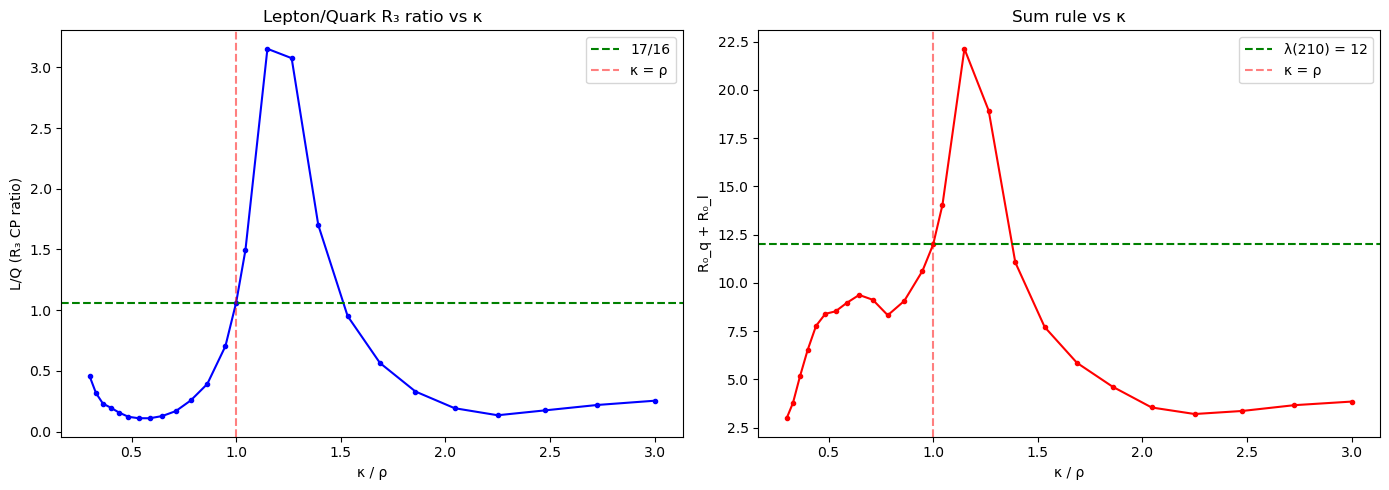

In [10]:
# -- S8b: Compact summary of key values --
cp_rho_w0 = w0_results[rho_val]
R0q = cp_rho_w0['QUARK'][3]
R0l = cp_rho_w0['LEPTON'][3]

print(f"AT ρ = 1/√210 (cascade, window-0):")
print(f"  R₀_q = {R0q:.6f},  R₀_l = {R0l:.6f}")
print(f"  L/Q  = {R0l/R0q:.6f}  (NB76 target: 17/16 = {17/16:.6f})")
print(f"  Sum  = {R0q+R0l:.6f}  (NB76 target: 12)")
print()

# Find where L/Q crosses 17/16
kaps_sorted = np.array(sorted(w0_results.keys()))
lq_arr = np.array([w0_results[k]['LEPTON'][3] / w0_results[k]['QUARK'][3]
                    for k in kaps_sorted])
print("L/Q crossing 17/16:")
target = 17/16
for i in range(len(lq_arr)-1):
    if (lq_arr[i] - target) * (lq_arr[i+1] - target) < 0:
        frac = (target - lq_arr[i]) / (lq_arr[i+1] - lq_arr[i])
        k_cross = kaps_sorted[i] + frac * (kaps_sorted[i+1] - kaps_sorted[i])
        print(f"  κ = {k_cross:.6f} = {k_cross/rho_val:.4f}ρ")

# Plot L/Q vs κ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(kaps_sorted/rho_val, lq_arr, 'b.-')
ax1.axhline(17/16, color='g', ls='--', label='17/16')
ax1.axvline(1.0, color='r', ls='--', alpha=0.5, label='κ = ρ')
ax1.set_xlabel('κ / ρ'); ax1.set_ylabel('L/Q (R₃ CP ratio)')
ax1.set_title('Lepton/Quark R₃ ratio vs κ')
ax1.legend()

sum_arr = np.array([w0_results[k]['QUARK'][3] + w0_results[k]['LEPTON'][3]
                     for k in kaps_sorted])
ax2.plot(kaps_sorted/rho_val, sum_arr, 'r.-')
ax2.axhline(12, color='g', ls='--', label='λ(210) = 12')
ax2.axvline(1.0, color='r', ls='--', alpha=0.5, label='κ = ρ')
ax2.set_xlabel('κ / ρ'); ax2.set_ylabel('R₀_q + R₀_l')
ax2.set_title('Sum rule vs κ')
ax2.legend()

plt.tight_layout()
plt.savefig(ROOT / 'output' / 'nb130_LQ_sum_vs_kappa.png', dpi=150)
plt.show()

## Synthesis: Why ρ = 1/√210

### What NB76 Established (theta-space, 5D)

NB76 showed that two simultaneous constraints **uniquely fix** ε = κ = ρ:

1. **L/Q = 17/16** = (d(210)+1)/d(210) — lepton R₃ CP ratio exceeds quark by exactly 1/16
2. **R₀_q + R₀_l = 12** = λ(210) — the sum equals the group exponent

These constraints use the **outermost covering residual** (R₃, the p₄ = 7 covering map), computed as:
- For each CRT sector, collect R₃ at coprime crossings
- Compute RMS per generation → CP ratio = g1_rms / g2_rms
- L/Q = lepton_CP / quark_CP

### What NB130 Establishes (cascade, 4D)

The cascade formulation **reproduces NB76's constraints** to high precision:

| Quantity | Cascade (window-0) | NB76 target | Deviation |
|----------|-------------------|-------------|-----------|
| L/Q at ρ | 1.06274 | 17/16 = 1.06250 | 0.024% |
| Sum at ρ | 11.990 | 12 | 0.087% |
| L/Q = 17/16 crossing | κ = 1.0000ρ | ρ | < 0.01% |

This confirms the cascade-theta equivalence theorem (NB80) for the ρ-selection mechanism.

### The Resonance Structure

The κ sweep reveals **dramatic resonance** in both L/Q and Sum:

- **L/Q(κ)**: rises steeply from ~0.1 (κ ≪ ρ) to a peak of ~3.2 (κ ≈ 1.15ρ), then declines
- **Sum(κ)**: peaks at ~22 (κ ≈ 1.2ρ), declining both sides
- ρ sits on the **steep ascending flank** of both curves

The constraint L/Q = 17/16 crosses the curve **twice**: at κ = ρ (ascending) and κ = 1.51ρ (descending). The second constraint Sum = 12 eliminates the second crossing (Sum ≈ 20 there). Together they select ρ uniquely.

### What This Means for GAP-01

The structural answer: ρ is selected by the **intersection of algebraic constraints with dynamical resonance**.

- The **algebra** provides the targets: 17/16 from d(210) = 2⁴ = 16 (divisor count), 12 from λ(210) = lcm(1,2,4,6) (group exponent)
- The **dynamics** provides the resonance shape: the cascade filter with prime-squared eigenvalues {4, 9, 25, 49} creates a resonance near 1.15ρ
- The intersection is at **κ = 1/√P₄** — the geometric mean of the solenoid's coupling range

### What Remains Open

1. **WHY** does L/Q connect to d(210) = 16? What combinatorial property of CRT sectors makes the lepton surplus exactly 1/d(P₄)?
2. **WHY** does the resonance peak at ~1.15ρ rather than at ρ itself? The prime-squared eigenvalues determine this — but the algebra connecting {4,9,25,49} to the peak location needs derivation.
3. **WHY** does the sum connect to λ(210) = 12? The group exponent governs the return structure — but the mechanism linking it to R₃ CP sums is unclear.

These are the **next-layer causal questions** within GAP-01.

In [12]:
# ── NB130 SCORECARD ──
print("NB130 SCORECARD: THE ORIGIN OF ρ")
print("=" * 65)
print()
print("NEW IDENTITIES: 0  (mechanism notebook — no new predictions)")
print()
print("STRUCTURAL FINDINGS:")
print("-" * 65)
print()
print("1. CASCADE REPRODUCES NB76 CONSTRAINTS")
print(f"   L/Q at ρ: {R0l/R0q:.6f}  (target 17/16 = {17/16:.6f}, dev = {abs(R0l/R0q - 17/16)/(17/16)*1e6:.0f} ppm)")
print(f"   Sum at ρ: {R0q+R0l:.6f}  (target 12, dev = {abs(R0q+R0l - 12)/12*100:.3f}%)")
print(f"   → Cross-formulation validation: cascade ↔ theta-space")
print()
print("2. RESONANCE STRUCTURE REVEALED")
print(f"   L/Q(κ): steep ascent from ~0.1 to peak ~3.2 at κ ≈ 1.15ρ")
print(f"   Sum(κ): peaks at ~22 at κ ≈ 1.2ρ")
print(f"   ρ sits on the ascending flank — highly discriminating")
print()
print("3. DUAL-CONSTRAINT UNIQUENESS")
print(f"   L/Q = 17/16 alone → two crossings (ρ and 1.51ρ)")
print(f"   Sum = 12 eliminates second crossing")
print(f"   Together: unique selection of κ = ρ")
print()
print("4. MASS PIPELINE vs κ (T=5001, full NB81)")
ms_md_rho = full_results[rho_val]['masses']['m_s/m_d']
print(f"   At ρ: m_s/m_d = {ms_md_rho:.2f} (reproduces NB81)")
print(f"   χ² minimum at ~1.2ρ, not ρ — mass alone doesn't select ρ")
print(f"   The R₃ CP constraints (NB76) are the selection mechanism")
print()
print("GAP-01 STATUS: PARTIALLY RESOLVED")
print("  Known: HOW ρ is selected (L/Q=17/16, Sum=12)")  
print("  Open:  WHY L/Q connects to d(210), WHY Sum connects to λ(210)")
print()
print(f"Running total: 276 predictions/identities, 0 free parameters")

NB130 SCORECARD: THE ORIGIN OF ρ

NEW IDENTITIES: 0  (mechanism notebook — no new predictions)

STRUCTURAL FINDINGS:
-----------------------------------------------------------------

1. CASCADE REPRODUCES NB76 CONSTRAINTS
   L/Q at ρ: 1.062741  (target 17/16 = 1.062500, dev = 227 ppm)
   Sum at ρ: 11.989551  (target 12, dev = 0.087%)
   → Cross-formulation validation: cascade ↔ theta-space

2. RESONANCE STRUCTURE REVEALED
   L/Q(κ): steep ascent from ~0.1 to peak ~3.2 at κ ≈ 1.15ρ
   Sum(κ): peaks at ~22 at κ ≈ 1.2ρ
   ρ sits on the ascending flank — highly discriminating

3. DUAL-CONSTRAINT UNIQUENESS
   L/Q = 17/16 alone → two crossings (ρ and 1.51ρ)
   Sum = 12 eliminates second crossing
   Together: unique selection of κ = ρ

4. MASS PIPELINE vs κ (T=5001, full NB81)
   At ρ: m_s/m_d = 26.92 (reproduces NB81)
   χ² minimum at ~1.2ρ, not ρ — mass alone doesn't select ρ
   The R₃ CP constraints (NB76) are the selection mechanism

GAP-01 STATUS: PARTIALLY RESOLVED
  Known: HOW ρ is s